In [1]:
from src.ColorsAnalysis import *
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
from IPython.display import clear_output
from src.fss_collapse_core import collapse_for_c, fit_linear_feedback_model, label
from src.stability_tests import read_dynamic_bundle
plt.style.use('properties.mplstyle')

In [2]:
n_lst = [1,2]

for n in n_lst:
    results_folder = f"../results/{n}Color/3D"
    configurations_folder = results_folder + "/configurations"
    create_folder(results_folder)
    create_folder(configurations_folder)

Folder already exists: ../results/1Color/3D
Folder already exists: ../results/1Color/3D/configurations
Folder already exists: ../results/2Color/3D
Folder already exists: ../results/2Color/3D/configurations


In [3]:
df_dynamic = pd.read_csv("../SOP_data/all_colors_dynamic.dat", sep=' ')
df_dynamic

,type_perc,dim,L,f_T,c,num_colors,P0,p0,N_samples,rho,nc,nc_err,nc_std,stat_window,stop_criterion,t_eq_validation,t_eq_s_prime_threshold,equilibrium_effective_rel_tol,post_equilibrium_extra_steps
0,bond,3,64,0.001000,0.001,1,0.2,0.6,1004,1.00000,0.992032,0.002807,0.088952,0,alive_species_pt_derivative_stability_or_death,discrete_derivative_of_blocked_pt_variation,0.00001,0.0025,100.0
1,bond,3,64,0.014759,0.001,1,0.2,0.6,502,1.00000,0.994024,0.003443,0.077151,0,alive_species_pt_derivative_stability_or_death,discrete_derivative_of_blocked_pt_variation,0.00001,0.0025,100.0
2,bond,3,64,0.028517,0.001,1,0.2,0.6,502,1.00000,1.000000,0.000000,0.000000,0,alive_species_pt_derivative_stability_or_death,discrete_derivative_of_blocked_pt_variation,0.00001,0.0025,100.0
3,bond,3,64,0.001000,0.005,1,0.2,0.6,502,1.00000,0.131474,0.015097,0.338255,0,alive_species_pt_derivative_stability_or_death,discrete_derivative_of_blocked_pt_variation,0.00001,0.0025,100.0
4,bond,3,64,0.014759,0.005,1,0.2,0.6,502,1.00000,0.575697,0.022081,0.494730,0,alive_species_pt_derivative_stability_or_death,discrete_derivative_of_blocked_pt_variation,0.00001,0.0025,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3669,bond,3,1024,0.379000,0.200,3,0.2,0.6,5,0.33333,3.000000,0.000000,0.000000,0,alive_species_pt_derivative_stability_or_death,discrete_derivative_of_blocked_pt_variation,0.00001,0.0025,100.0
3670,bond,3,128,0.400000,0.200,3,0.2,0.6,302,0.33333,3.000000,0.000000,0.000000,0,alive_species_pt_derivative_stability_or_death,discrete_derivative_of_blocked_pt_variation,0.00001,0.0025,100.0
3671,bond,3,256,0.400000,0.200,3,0.2,0.6,150,0.33333,3.000000,0.000000,0.000000,0,alive_species_pt_derivative_stability_or_death,discrete_derivative_of_blocked_pt_variation,0.00001,0.0025,100.0
3672,bond,3,512,0.400000,0.200,3,0.2,0.6,25,0.33333,3.000000,0.000000,0.000000,0,alive_species_pt_derivative_stability_or_death,discrete_derivative_of_blocked_pt_variation,0.00001,0.0025,100.0


In [4]:
df_series = pd.read_csv('../SOP_data/all_data_dynamic.dat', sep=' ')
df_series

,type_perc,dim,L,f_T,c,nc,rho,p0,P0,order,...,z_max_mean,z_max_err,z_stat_mean,z_stat_err,stat_window,stop_criterion,t_eq_validation,t_eq_s_prime_threshold,equilibrium_effective_rel_tol,post_equilibrium_extra_steps
0,bond,3,64,0.001000,0.001,1,1.00000,0.6,0.2,0,...,452.640562,0.256744,436.367470,0.276080,0,alive_species_pt_derivative_stability_or_death,discrete_derivative_of_blocked_pt_variation,0.00001,0.0025,100.0
1,bond,3,64,0.014759,0.001,1,1.00000,0.6,0.2,0,...,463.703407,0.409916,445.416834,0.427283,0,alive_species_pt_derivative_stability_or_death,discrete_derivative_of_blocked_pt_variation,0.00001,0.0025,100.0
2,bond,3,64,0.028517,0.001,1,1.00000,0.6,0.2,0,...,472.657371,0.403438,452.336653,0.446670,0,alive_species_pt_derivative_stability_or_death,discrete_derivative_of_blocked_pt_variation,0.00001,0.0025,100.0
3,bond,3,64,0.001000,0.005,1,1.00000,0.6,0.2,0,...,121.484848,1.139714,111.954545,0.695450,0,alive_species_pt_derivative_stability_or_death,discrete_derivative_of_blocked_pt_variation,0.00001,0.0025,100.0
4,bond,3,64,0.014759,0.005,1,1.00000,0.6,0.2,0,...,126.449827,0.451613,115.674740,0.318918,0,alive_species_pt_derivative_stability_or_death,discrete_derivative_of_blocked_pt_variation,0.00001,0.0025,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6700,bond,3,512,0.400000,0.200,3,0.33333,0.6,0.2,1,...,150.000000,0.000000,60.000000,0.000000,0,alive_species_pt_derivative_stability_or_death,discrete_derivative_of_blocked_pt_variation,0.00001,0.0025,100.0
6701,bond,3,512,0.400000,0.200,3,0.33333,0.6,0.2,2,...,150.000000,0.000000,60.000000,0.000000,0,alive_species_pt_derivative_stability_or_death,discrete_derivative_of_blocked_pt_variation,0.00001,0.0025,100.0
6702,bond,3,1024,0.400000,0.200,3,0.33333,0.6,0.2,0,...,150.000000,0.000000,60.000000,0.000000,0,alive_species_pt_derivative_stability_or_death,discrete_derivative_of_blocked_pt_variation,0.00001,0.0025,100.0
6703,bond,3,1024,0.400000,0.200,3,0.33333,0.6,0.2,1,...,150.000000,0.000000,60.000000,0.000000,0,alive_species_pt_derivative_stability_or_death,discrete_derivative_of_blocked_pt_variation,0.00001,0.0025,100.0


# 3D

## $p^*$ => $n_s = 1$

[0.01475862, 0.02851724, 0.04227586, 0.05603448, 0.0697931, 0.08355172, 0.09731034, 0.111069, 0.1248276, 0.1385862, 0.1523448, 0.1661034, 0.1798621, 0.1936207, 0.2073793, 0.2211379, 0.2348966, 0.2486552, 0.2624138, 0.2761724, 0.289931, 0.3036897, 0.3174483, 0.3312069]
[0.001, 0.002105263, 0.003210526, 0.004315789, 0.005421053, 0.006526316, 0.007631579, 0.008736842, 0.009842105, 0.01094737, 0.01205263, 0.01315789, 0.01426316, 0.01536842, 0.01647368, 0.01757895, 0.01868421, 0.01978947, 0.02089474, 0.022, 0.043, 0.064, 0.085, 0.106, 0.127, 0.148, 0.169, 0.19, 0.211, 0.232, 0.253, 0.274, 0.295, 0.316, 0.337]
[0.001, 0.002105263, 0.003210526, 0.004315789, 0.005421053, 0.006526316, 0.007631579, 0.008736842, 0.009842105, 0.01094737, 0.01205263, 0.01315789, 0.01426316, 0.01536842, 0.01647368, 0.01757895, 0.01868421, 0.01978947, 0.02089474, 0.022, 0.043, 0.064, 0.085, 0.106, 0.127, 0.148, 0.169, 0.19, 0.211, 0.232, 0.253, 0.274, 0.295, 0.316]
[0.001, 0.002105263, 0.003210526, 0.004315789, 0.005

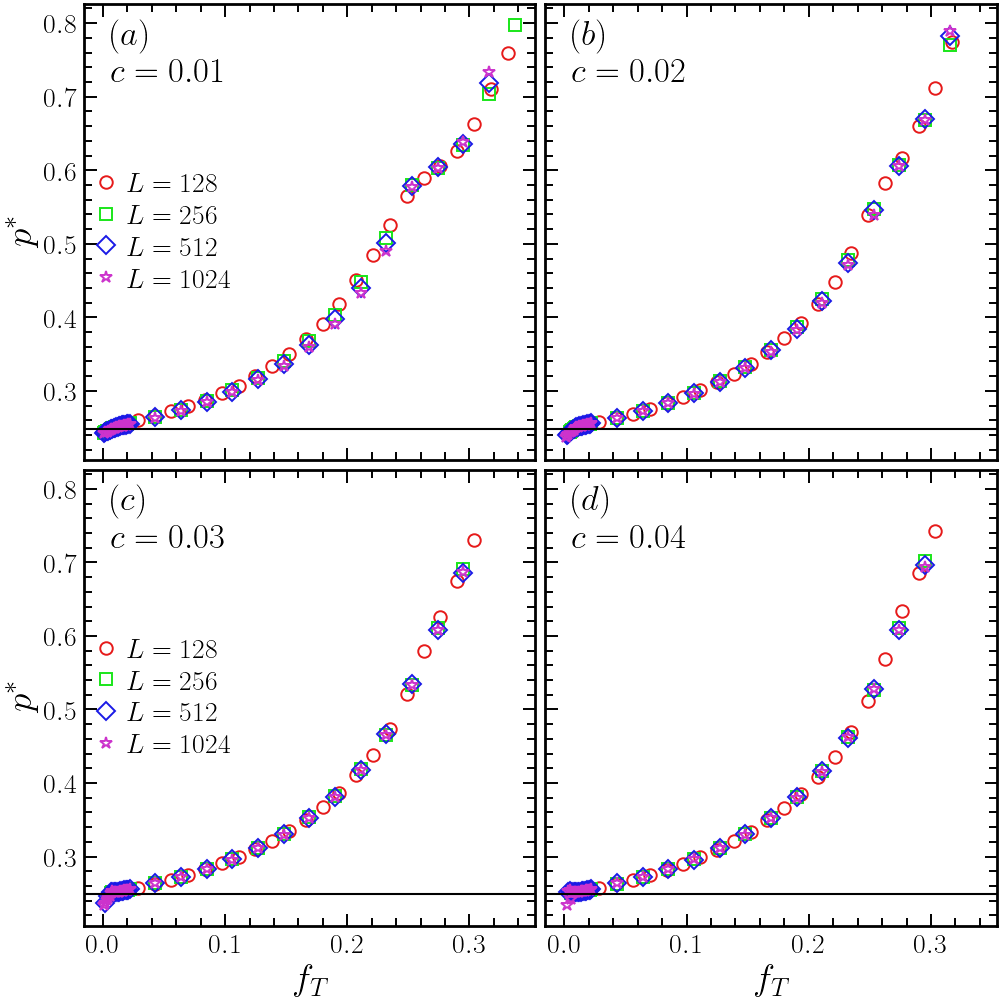

In [11]:
#plt.plot(df_series[(df_series['nc']==4) & (df_dynamic['c']==0.01)]['f_T'],df_dynamic[(df_dynamic['nc']==4) & (df_dynamic['c']==0.01)]['p_mean'], 'o')
L_lst = [128, 256, 512, 1024]
#L_lst = [256]
nc = 3
rho = 1/nc
order = 0
p0 = 0.6
P0 = 0.2
dim = 3
c = 0.01
middle_points = []
markers = ['o', 's', 'D', '*']
order = 0
base = 5
#c_lst = [0.01, 0.05, 0.1, 0.15]
c_lst = [0.01, 0.02, 0.03, 0.04]
fs_l_fig = 25
fs_label = 27
pc = 0.24881182
ms = 9
fig, axes = plt.subplots(2, 2, figsize=(2*base, 2*base), constrained_layout=True, sharey=True, sharex=True)
labels = [r"$(a)$", r"$(b)$", r"$(c)$", r"$(d)$"]
for idx_c, ax in enumerate(axes.flatten()):
        c = c_lst[idx_c]
        for idx, L in enumerate(L_lst):
                df_SUB = df_series[(df_series['type_perc']=='bond') & (df_series['p0']==p0) & (df_series['P0']==P0)
                        & (df_series['order']==order) & (df_series['nc']==nc) & (df_series['L']==L)
                        & (df_series['c']==c) & (df_series['dim']==dim)].sort_values(by='f_T').reset_index(drop=True)
                df_filter = df_SUB[df_SUB['N_samples']==df_SUB['N_samples_perc']]
                
                df_plot = df_filter.sort_values("f_T").copy()
                
                df_plot = df_plot[(df_plot["p_mean"] >= 0) & (df_plot["p_mean"] <= 1)]
                df_plot = df_plot[df_plot["N_samples_perc"] >= 5]
                df_plot = df_plot[df_plot["p_mean"] < 0.80]  # se quiser remover regime saturado
                
                index = df_plot.index[df_plot["p_mean"] >= 0.8] 
                if len(index) > 0:
                        index_cut = index[0]
                        df_trunc = df_plot.loc[:index_cut].copy()
                else:
                        df_trunc = df_plot.copy()

                x = df_trunc['f_T'] #f_t

                y = df_trunc['p_mean'] #p_t
                print(x.to_list())
                ax.plot(x, y, markers[idx], ms=ms,mew=1.4,label=f'$L={L}$')
        
        ax.text(0.06, 0.83, f'{labels[idx_c]} \n $c = {c}$', transform=ax.transAxes , fontsize=fs_l_fig)
        ax.axhline(y=pc, color='k')
for ax in axes[:,0]:
        ax.legend(loc='best')
        ax.set_ylabel(r"$p^*$",fontsize=fs_label)
for ax in axes[1,:]:
        ax.set_xlabel(r"$f_T$",fontsize=fs_label)
#plt.legend()
#plt.savefig(f"../results/{nc}Color/3D/p_mean_3D_ns_1.pdf")
plt.show()

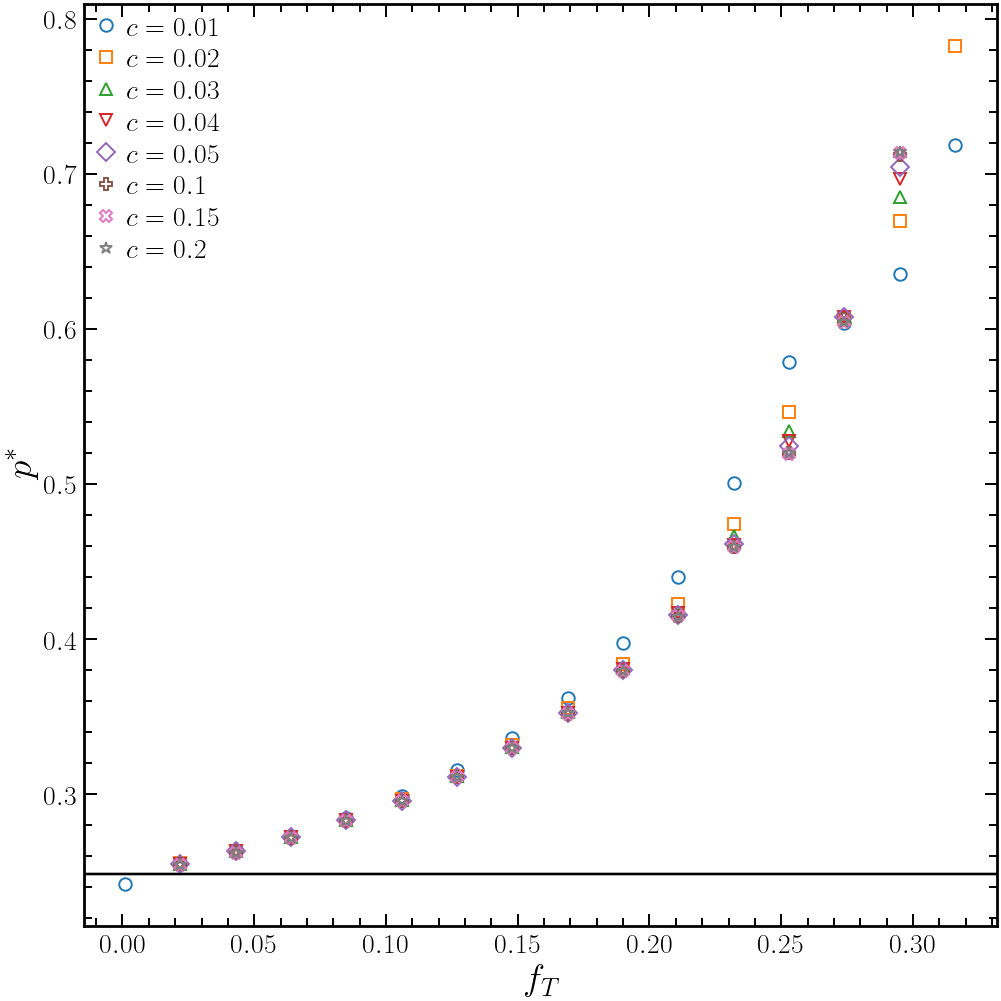

In [27]:
#plt.plot(df_series[(df_series['nc']==4) & (df_dynamic['c']==0.01)]['f_T'],df_dynamic[(df_dynamic['nc']==4) & (df_dynamic['c']==0.01)]['p_mean'], 'o')
L = 512 
#L_lst = [256]
nc = 3
rho = 1/nc
order = 0
p0 = 0.6
P0 = 0.2
dim = 3
c = 0.01
middle_points = []
markers = ['o', 's', 'D', '*']
order = 0
base = 5
#c_lst = [0.01, 0.05, 0.1, 0.15]
c_lst = [0.01, 0.02, 0.03, 0.04, 0.05, 0.1, 0.15, 0.2]
fs_l_fig = 25
fs_label = 27
pc = 0.24881182
ms = 9
fig, ax = plt.subplots(1, 1, figsize=(2*base, 2*base), constrained_layout=True, sharey=True, sharex=True)

markers = ['o', 's', '^', 'v', 'D', 'P', 'X', '*']

colors = [
    'tab:blue',
    'tab:orange',
    'tab:green',
    'tab:red',
    'tab:purple',
    'tab:brown',
    'tab:pink',
    'tab:gray'
]
#labels = [r"$(a)$", r"$(b)$", r"$(c)$", r"$(d)$"]
for idx_c, sas in enumerate(c_lst):
    c = c_lst[idx_c]

    df_SUB = df_series[(df_series['type_perc']=='bond') & (df_series['p0']==p0) & (df_series['P0']==P0)
            & (df_series['order']==order) & (df_series['nc']==nc) & (df_series['L']==L)
            & (df_series['c']==c) & (df_series['dim']==dim)].sort_values(by='f_T').reset_index(drop=True)
    df_filter = df_SUB[df_SUB['N_samples']==df_SUB['N_samples_perc']]
    
    df_plot = df_filter.sort_values("f_T").copy()
    
    df_plot = df_plot[(df_plot["p_mean"] >= 0) & (df_plot["p_mean"] <= 1)]
    df_plot = df_plot[df_plot["N_samples_perc"] >= 5]
    df_plot = df_plot[df_plot["p_mean"] < 0.80]  # se quiser remover regime saturado
    
    index = df_plot.index[df_plot["p_mean"] >= 0.8] 
    if len(index) > 0:
            index_cut = index[0]
            df_trunc = df_plot.loc[:index_cut].copy()
    else:
            df_trunc = df_plot.copy()

    x = df_trunc['f_T'] #f_t

    y = df_trunc['p_mean'] #p_t
    
    ax.plot(x, y, marker=markers[idx_c], color=colors[idx_c],ls="None", ms=ms, mew=1.4, label=f'$c={c}$')
    
    #ax.text(0.06, 0.83, f'{labels[idx_c]} \n $c = {c}$', transform=ax.transAxes , fontsize=fs_l_fig)
    ax.axhline(y=pc, color='k')

ax.legend(loc='best')
ax.set_ylabel(r"$p^*$",fontsize=fs_label)

ax.set_xlabel(r"$f_T$",fontsize=fs_label)
#plt.legend()
#plt.savefig(f"../results/{nc}Color/3D/p_mean_3D_ns_1.pdf")
plt.show()

0.0465101
0.0480975
0.05603448
0.0697931


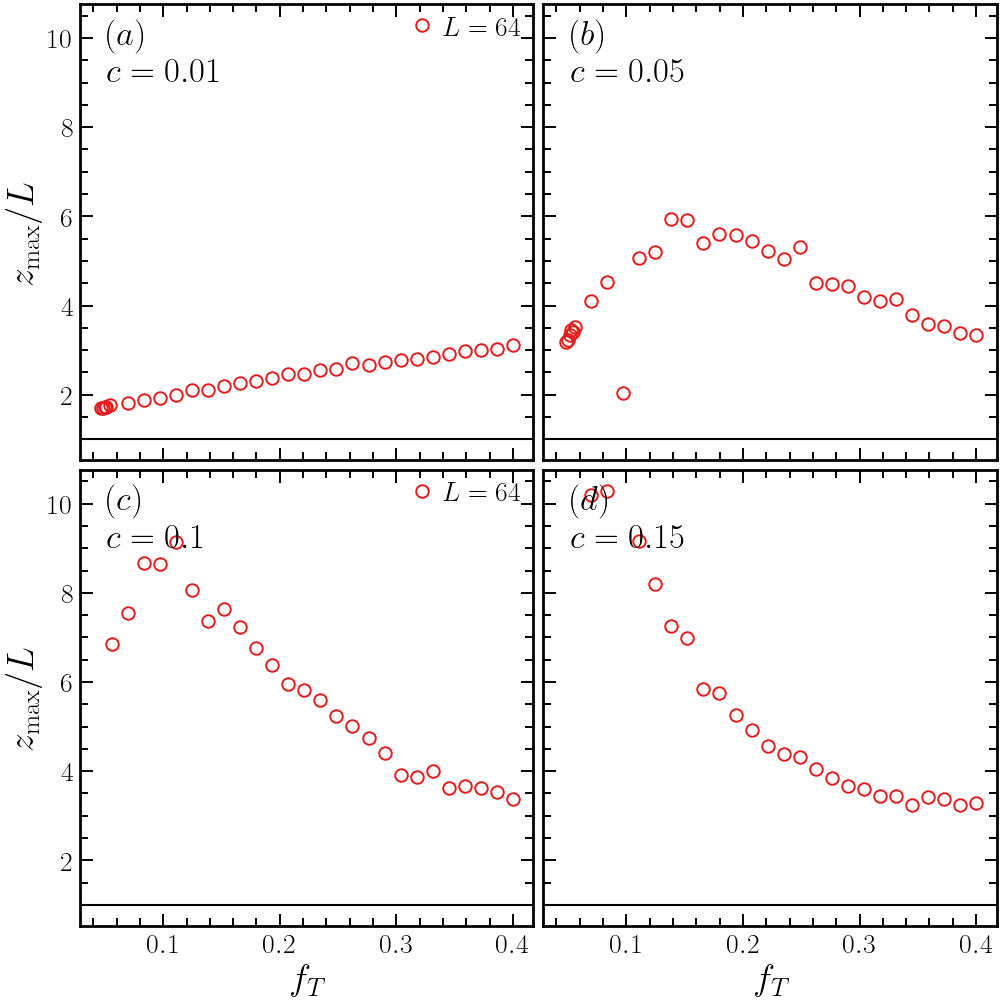

In [16]:
#plt.plot(df_series[(df_series['nc']==4) & (df_dynamic['c']==0.01)]['f_T'],df_dynamic[(df_dynamic['nc']==4) & (df_dynamic['c']==0.01)]['p_mean'], 'o')
#L_lst = [256, 512, 1024]
L_lst = [64]
nc = 1
rho = 1/nc
order = 0
p0 = 0.6
P0 = 0.2
dim = 3
c = 0.01
middle_points = []
markers = ['o', 's', 'D', '*']
order = 0
base = 5
c_lst = [0.01, 0.05, 0.1, 0.15]
fs_l_fig = 25
fs_label = 27
pc = 0.24881182
ms = 9
fig, axes = plt.subplots(2, 2, figsize=(2*base, 2*base), constrained_layout=True, sharey=True, sharex=True)
labels = [r"$(a)$", r"$(b)$", r"$(c)$", r"$(d)$"]
for idx_c, ax in enumerate(axes.flatten()):
        c = c_lst[idx_c]
        for idx, L in enumerate(L_lst):
                df_SUB = df_series[(df_series['type_perc']=='bond') & (df_series['p0']==p0) & (df_series['P0']==P0)
                        & (df_series['order']==order) & (df_series['nc']==nc) & (df_series['L']==L)
                        & (df_series['c']==c) & (df_series['dim']==dim)].sort_values(by='f_T').reset_index(drop=True)
                df_filter = df_SUB[df_SUB['N_samples']==df_SUB['N_samples_perc']]
                
                df_plot = df_filter.sort_values("f_T").copy()
                
                df_plot = df_plot[(df_plot["p_mean"] >= 0) & (df_plot["p_mean"] <= 1)]
                df_plot = df_plot[df_plot["N_samples_perc"] >= 5]
                df_plot = df_plot[df_plot["p_mean"] < 0.90]  # se quiser remover regime saturado
                
                index = df_plot.index[df_plot["p_mean"] >= 0.9] 
                if len(index) > 0:
                        index_cut = index[0]
                        df_trunc = df_plot.loc[:index_cut].copy()
                else:
                        df_trunc = df_plot.copy()

                x = df_trunc['f_T'] #f_t
                y = df_trunc['z_max_mean']/L #p_t
                print(min(x))
                ax.plot(x, y, markers[idx], ms=ms,mew=1.4,label=f'$L={L}$')
        
        ax.text(0.06, 0.83, f'{labels[idx_c]} \n $c = {c}$', transform=ax.transAxes , fontsize=fs_l_fig)
        ax.axhline(y=1, color='k')
for ax in axes[:,0]:
        ax.legend(loc='best')
        ax.set_ylabel(r"$z_{\max}/L$",fontsize=fs_label)
for ax in axes[1,:]:
        ax.set_xlabel(r"$f_T$",fontsize=fs_label)
#plt.legend()
#plt.savefig(f"../results/{nc}Color/3D/p_mean_3D_ns_1.pdf")
plt.show()

## $p^*$ => $n_s = 2$

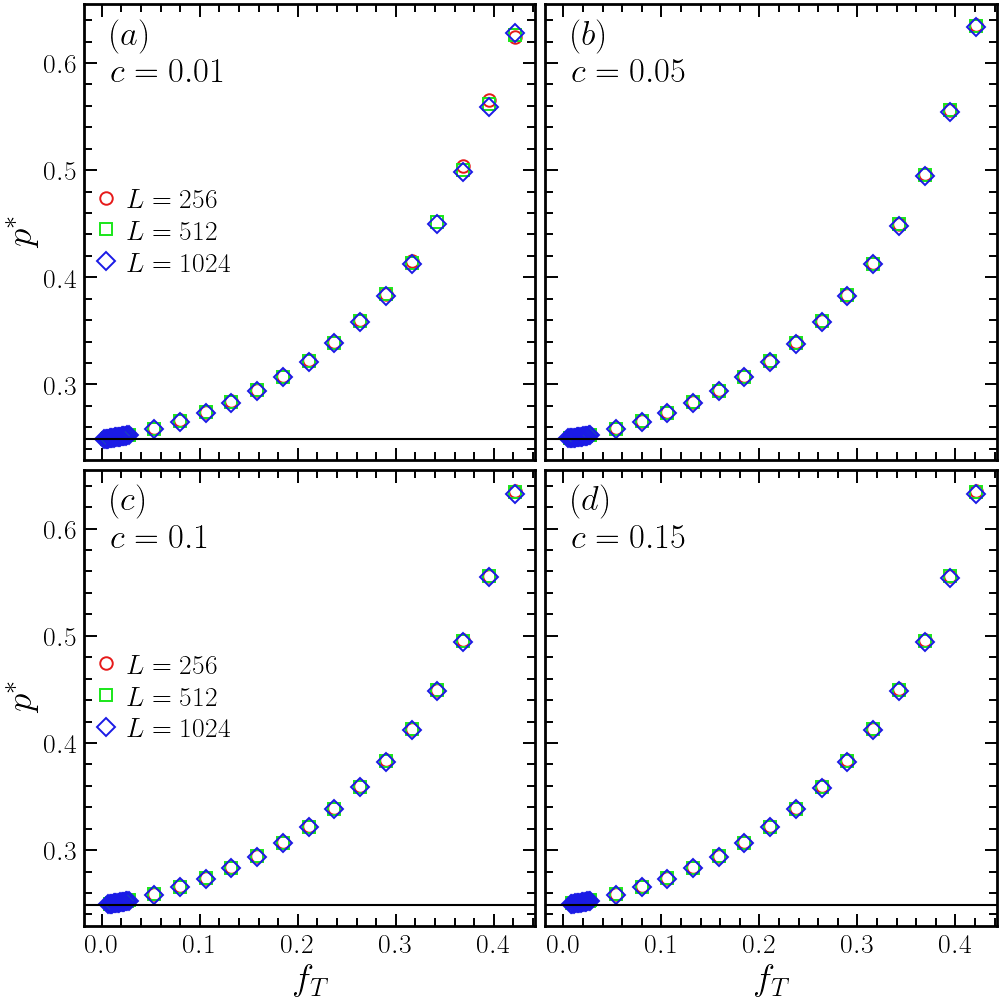

In [13]:
#plt.plot(df_series[(df_series['nc']==4) & (df_dynamic['c']==0.01)]['f_T'],df_dynamic[(df_dynamic['nc']==4) & (df_dynamic['c']==0.01)]['p_mean'], 'o')
L_lst = [256, 512, 1024]
nc = 2
rho = 1/nc
order = 0
p0 = 0.6
P0 = 1.0
dim = 3
c = 0.01
middle_points = []
markers = ['o', 's', 'D', '*']
order = 0
base = 5
c_lst = [0.01, 0.05, 0.1, 0.15]
fs_l_fig = 25
fs_label = 27
pc = 0.24881182
ms = 9
fig, axes = plt.subplots(2, 2, figsize=(2*base, 2*base), constrained_layout=True, sharey=True, sharex=True)
labels = [r"$(a)$", r"$(b)$", r"$(c)$", r"$(d)$"]
for idx_c, ax in enumerate(axes.flatten()):
        c = c_lst[idx_c]
        for idx, L in enumerate(L_lst):
                df_SUB = df_series[(df_series['type_perc']=='bond') & (df_series['p0']==p0) & (df_series['P0']==P0)
                        & (df_series['order']==order) & (df_series['nc']==nc) & (df_series['L']==L)
                        & (df_series['c']==c) & (df_series['dim']==dim)].sort_values(by='f_T').reset_index(drop=True)
                df_filter = df_SUB[df_SUB['N_samples']==df_SUB['N_samples_perc']]
                
                df_plot = df_filter.sort_values("f_T").copy()
                
                df_plot = df_plot[(df_plot["p_mean"] >= 0) & (df_plot["p_mean"] <= 1)]
                df_plot = df_plot[df_plot["N_samples_perc"] >= 5]
                df_plot = df_plot[df_plot["p_mean"] < 0.70]  # se quiser remover regime saturado
                
                index = df_plot.index[df_plot["p_mean"] >= 0.7] 
                if len(index) > 0:
                        index_cut = index[0]
                        df_trunc = df_plot.loc[:index_cut].copy()
                else:
                        df_trunc = df_plot.copy()

                x = df_trunc['f_T'] #f_t
                y = df_trunc['p_mean'] #p_t
                ax.plot(x, y, markers[idx], ms=ms,mew=1.4,label=f'$L={L}$')
        
        ax.text(0.06, 0.83, f'{labels[idx_c]} \n $c = {c}$', transform=ax.transAxes , fontsize=fs_l_fig)
        ax.axhline(y=pc, color='k')
for ax in axes[:,0]:
        ax.legend(loc='best')
        ax.set_ylabel(r"$p^*$",fontsize=fs_label)
for ax in axes[1,:]:
        ax.set_xlabel(r"$f_T$",fontsize=fs_label)
#plt.legend()
plt.savefig(f"../results/{nc}Color/3D/p_mean_3D_ns_1.pdf")
plt.show()

## Adjust for $n_s = 1$

c=0.01, L=256: f_T_min=0.01482272, f_T_max=0.50000000, N=28
c=0.01, L=512: f_T_min=0.00929363, f_T_max=0.50000000, N=32
c=0.01, L=1024: f_T_min=0.00652909, f_T_max=0.50000000, N=34

===== Melhor colapso =====
c           = 0.01
lambda_best = 0.570000
R2_best     = 0.9999590499
RMSE_best   = 1.9327672716e-04
A_shift     = -2.9228128913e-03
B_vert      = 2.8874455959e-02
c=0.05, L=256: f_T_min=0.02173407, f_T_max=0.50000000, N=23
c=0.05, L=512: f_T_min=0.01482272, f_T_max=0.50000000, N=28
c=0.05, L=1024: f_T_min=0.01205817, f_T_max=0.50000000, N=30

===== Melhor colapso =====
c           = 0.05
lambda_best = 0.620000
R2_best     = 0.9999764677
RMSE_best   = 1.4792055161e-04
A_shift     = -6.1030042626e-02
B_vert      = 2.1056466395e-02
c=0.1, L=256: f_T_min=0.02588089, f_T_max=0.50000000, N=19
c=0.1, L=512: f_T_min=0.02035180, f_T_max=0.50000000, N=24
c=0.1, L=1024: f_T_min=0.01482272, f_T_max=0.50000000, N=28

===== Melhor colapso =====
c           = 0.1
lambda_best = 0.570000
R2_best  

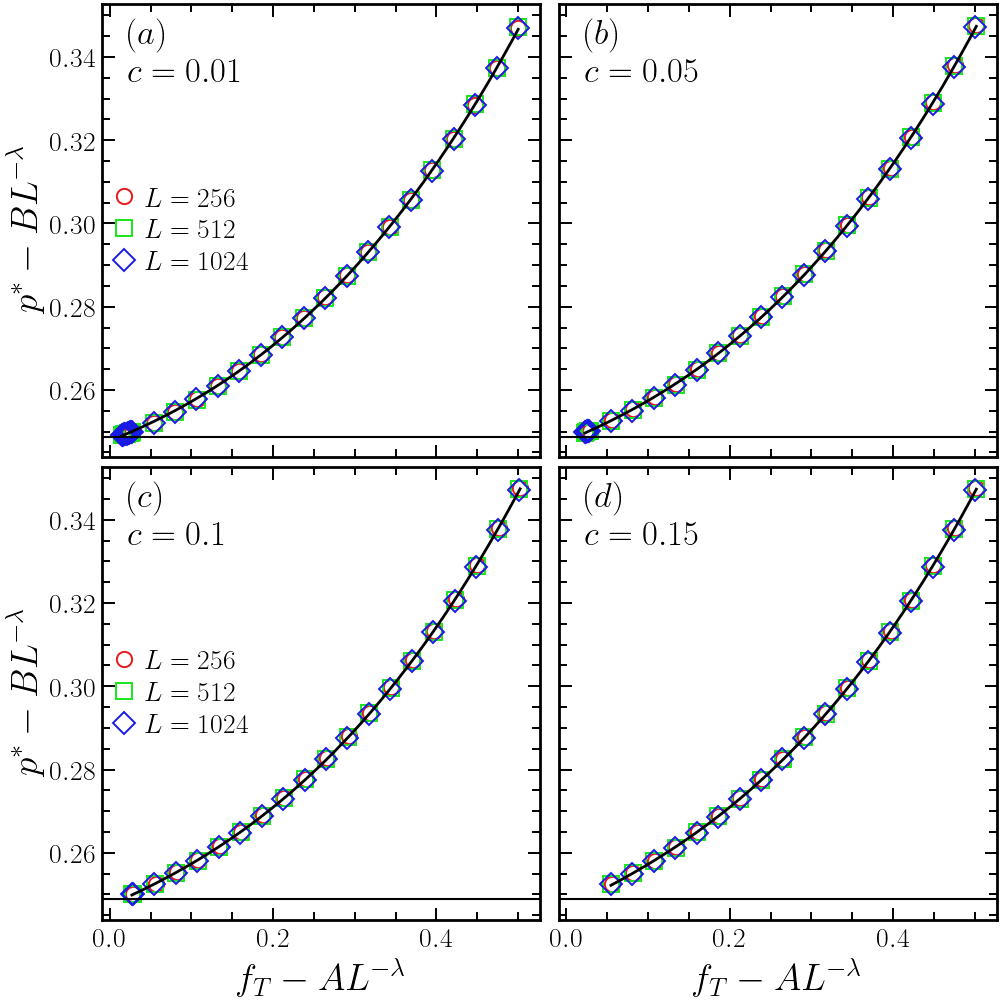

In [5]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(2 * base, 2 * base),
    constrained_layout=True,
    sharey=True,
    sharex=True,
)
nc  = 1
results_by_c = {}

for idx_c, ax in enumerate(axes.flatten()):
    c = c_lst[idx_c]

    result = collapse_for_c(
        df_series=df_series,
        c=c,
        L_lst=L_lst,
        nc=nc,
        p0=p0,
        P0=P0,
        order=order,
        dim=dim,
        type_perc='bond',
        min_samples_perc=5,
        p_cut=0.80,
        p_cut_mode='remove',
        domain_mode='common',
        degree=3,
        lambda_min=0.4,
        lambda_max=1.4,
        n_lambda=101,
        verbose=True,
    )

    results_by_c[c] = result

    for idx, L in enumerate(L_lst):
        df_col = result["collapse_data"][L]

        ax.plot(
            df_col["x_col"],
            df_col["y_col"],
            markers[idx],
            ms=11,
            mew=1.4,
            label=f'$L={L}$'
        )

    fit_curve = result["fit_curve"]
    
    ax.plot(
        fit_curve["x"],
        fit_curve["y"],
        'k-',
        lw=2.0,
#        label=r'$F_\infty$'
    )

    ax.text(
        0.06,
        0.83,
        f'{labels[idx_c]} \n $c = {c}$',
        transform=ax.transAxes,
        fontsize=fs_l_fig,
    )
    ax.axhline(y=pc, color='k')
for ax in axes[:, 0]:
    ax.legend(loc='best')
    ax.set_ylabel(
        r"$p^* - B L^{-\lambda}$",
        fontsize=fs_label,
    )

for ax in axes[1, :]:
    ax.set_xlabel(
        r"$f_T - A L^{-\lambda}$",
        fontsize=fs_label,
    )
plt.savefig(f"../results/{nc}Color/3D/collapse_p_mean_3D_ns_1.pdf")
plt.show()

## Adjust for $n_s = 2$

c=0.01, L=256: f_T_min=0.00929363, f_T_max=0.42121050, N=28
c=0.01, L=512: f_T_min=0.00514681, f_T_max=0.42121050, N=32
c=0.01, L=1024: f_T_min=0.00238227, f_T_max=0.42121050, N=34

===== Melhor colapso =====
c           = 0.01
lambda_best = 0.971000
R2_best     = 0.9994170246
RMSE_best   = 2.4151519904e-03
A_shift     = -3.9216142911e-01
B_vert      = 1.6038283721e-01
c=0.05, L=256: f_T_min=0.00929363, f_T_max=0.42121050, N=29
c=0.05, L=512: f_T_min=0.00652909, f_T_max=0.42121050, N=31
c=0.05, L=1024: f_T_min=0.00514681, f_T_max=0.42121050, N=32

===== Melhor colapso =====
c           = 0.05
lambda_best = 0.100000
R2_best     = 0.9987700563
RMSE_best   = 3.5209144766e-03
A_shift     = -6.9032565823e-03
B_vert      = 7.6374289667e-03
c=0.1, L=256: f_T_min=0.01067590, f_T_max=0.42121050, N=28
c=0.1, L=512: f_T_min=0.00791136, f_T_max=0.42121050, N=30
c=0.1, L=1024: f_T_min=0.00652909, f_T_max=0.42121050, N=31

===== Melhor colapso =====
c           = 0.1
lambda_best = 0.269000
R2_best  

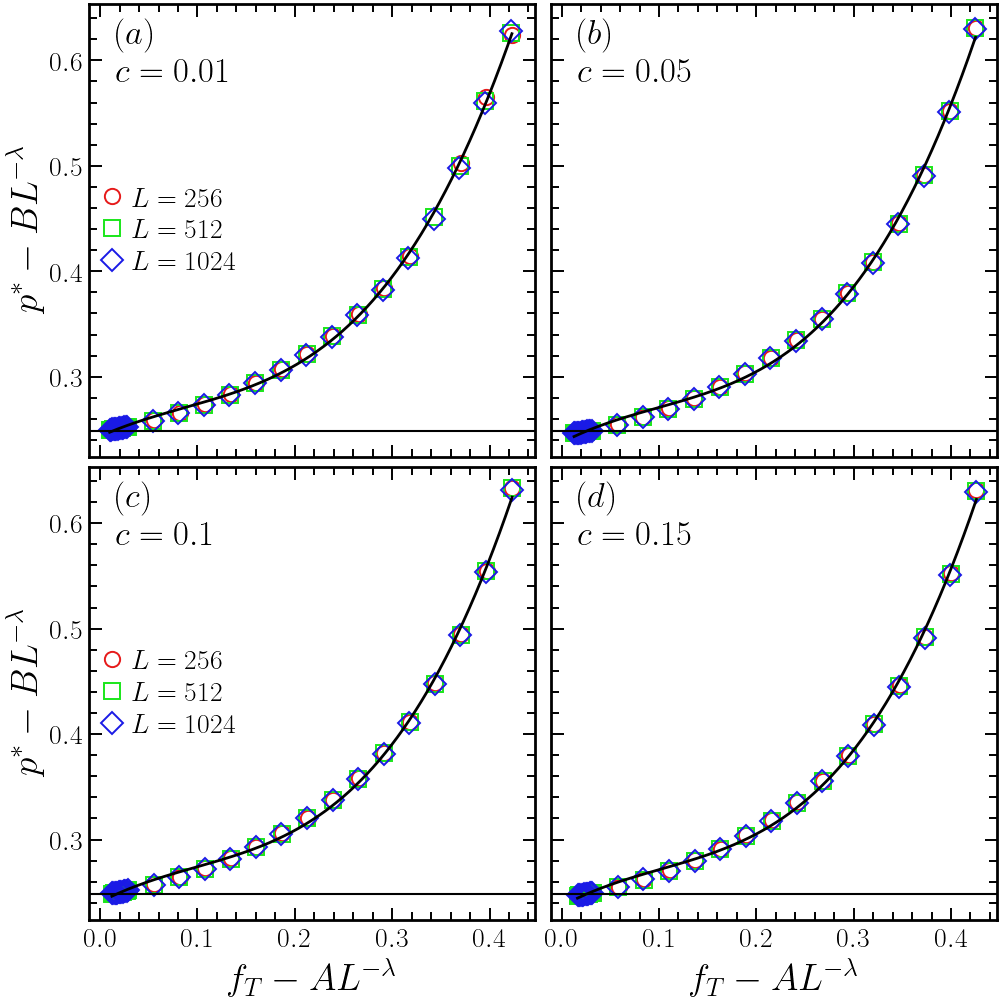

In [15]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(2 * base, 2 * base),
    constrained_layout=True,
    sharey=True,
    sharex=True,
)
nc  = 2
results_by_c = {}

for idx_c, ax in enumerate(axes.flatten()):
    c = c_lst[idx_c]

    result = collapse_for_c(
        df_series=df_series,
        c=c,
        L_lst=L_lst,
        nc=nc,
        p0=p0,
        P0=P0,
        order=order,
        dim=dim,
        type_perc='bond',
        min_samples_perc=5,
        p_cut=0.70,
        p_cut_mode='remove',
        domain_mode='common',
        degree=3,
        lambda_min=0.1,
        lambda_max=1.4,
        n_lambda=101,
        verbose=True,
    )

    results_by_c[c] = result

    for idx, L in enumerate(L_lst):
        df_col = result["collapse_data"][L]

        ax.plot(
            df_col["x_col"],
            df_col["y_col"],
            markers[idx],
            ms=11,
            mew=1.4,
            label=f'$L={L}$'
        )

    fit_curve = result["fit_curve"]
    
    ax.plot(
        fit_curve["x"],
        fit_curve["y"],
        'k-',
        lw=2.0,
#        label=r'$F_\infty$'
    )

    ax.text(
        0.06,
        0.83,
        f'{labels[idx_c]} \n $c = {c}$',
        transform=ax.transAxes,
        fontsize=fs_l_fig,
    )
    ax.axhline(y=pc, color='k')
for ax in axes[:, 0]:
    ax.legend(loc='best')
    ax.set_ylabel(
        r"$p^* - B L^{-\lambda}$",
        fontsize=fs_label,
    )

for ax in axes[1, :]:
    ax.set_xlabel(
        r"$f_T - A L^{-\lambda}$",
        fontsize=fs_label,
    )
plt.savefig(f"../results/{nc}Color/3D/collapse_p_mean_3D_ns_1.pdf")
plt.show()

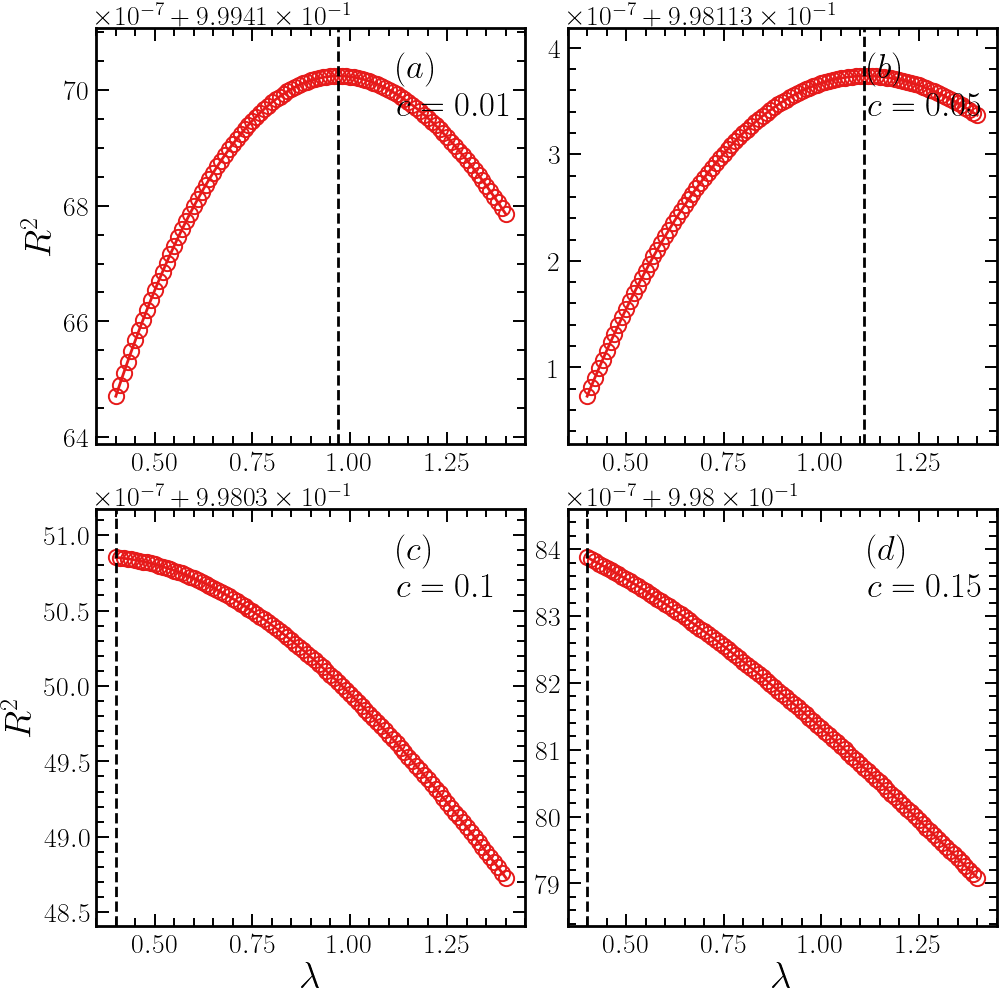

In [ ]:
nc = 1
fig, axes = plt.subplots(
    2,
    2,
    figsize=(2 * base, 2 * base),
    constrained_layout=True,
    sharex=True,
    sharey=False,
)

for idx_c, ax in enumerate(axes.flatten()):

    c = c_lst[idx_c]

    result = results_by_c[c]
    scan = result["scan"]

    x = scan["lambda"].to_numpy()
    y = scan["R2"].to_numpy()

    ax.plot(
        x,
        y,
        'o-',
        ms=11,
        mew=1.4,
        lw=2.0,
    )

    ax.axvline(
        result["lambda_best"],
        color='k',
        ls='--',
        lw=2.0,
    )

    # Zoom local no R² de cada subplot
    y_min = np.nanmin(y)
    y_max = np.nanmax(y)
    dy = y_max - y_min

    if dy == 0:
        dy = abs(y_min) * 0.05 if y_min != 0 else 1e-8

    pad = 0.15
    ax.set_ylim(
        y_min - pad * dy,
        y_max + pad * dy
    )

    ax.text(
        0.7,
        0.79,
        f'{labels[idx_c]} \n $c = {c}$',
        transform=ax.transAxes,
        fontsize=fs_l_fig,
    )

    # Mantém ticks nos quatro lados, mas sem controlar tamanho manualmente
    ax.tick_params(
        axis='both',
        which='both',
        direction='in',
        top=True,
        right=True,
        labelleft=True,
        labelbottom=True,
    )

    ax.minorticks_on()

for ax in axes[:, 0]:
    ax.set_ylabel(r"$R^2$", fontsize=fs_label)

for ax in axes[1, :]:
    ax.set_xlabel(r"$\lambda$", fontsize=fs_label)

plt.savefig(f"../results/{nc}Color/3D/R2_lambda_3D_ns_1.pdf")
plt.show()

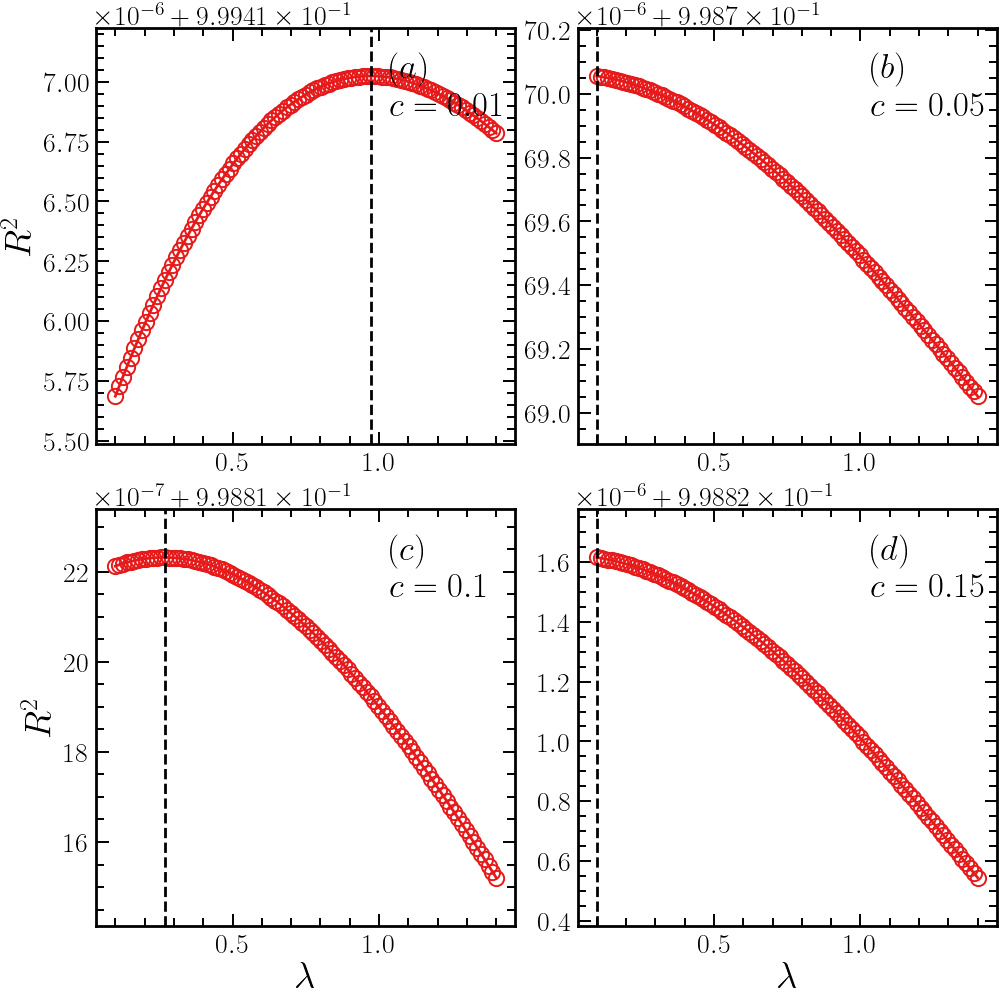

In [16]:
nc = 2
fig, axes = plt.subplots(
    2,
    2,
    figsize=(2 * base, 2 * base),
    constrained_layout=True,
    sharex=True,
    sharey=False,
)

for idx_c, ax in enumerate(axes.flatten()):

    c = c_lst[idx_c]

    result = results_by_c[c]
    scan = result["scan"]

    x = scan["lambda"].to_numpy()
    y = scan["R2"].to_numpy()

    ax.plot(
        x,
        y,
        'o-',
        ms=11,
        mew=1.4,
        lw=2.0,
    )

    ax.axvline(
        result["lambda_best"],
        color='k',
        ls='--',
        lw=2.0,
    )

    # Zoom local no R² de cada subplot
    y_min = np.nanmin(y)
    y_max = np.nanmax(y)
    dy = y_max - y_min

    if dy == 0:
        dy = abs(y_min) * 0.05 if y_min != 0 else 1e-8

    pad = 0.15
    ax.set_ylim(
        y_min - pad * dy,
        y_max + pad * dy
    )

    ax.text(
        0.7,
        0.79,
        f'{labels[idx_c]} \n $c = {c}$',
        transform=ax.transAxes,
        fontsize=fs_l_fig,
    )

    # Mantém ticks nos quatro lados, mas sem controlar tamanho manualmente
    ax.tick_params(
        axis='both',
        which='both',
        direction='in',
        top=True,
        right=True,
        labelleft=True,
        labelbottom=True,
    )

    ax.minorticks_on()

for ax in axes[:, 0]:
    ax.set_ylabel(r"$R^2$", fontsize=fs_label)

for ax in axes[1, :]:
    ax.set_xlabel(r"$\lambda$", fontsize=fs_label)

plt.savefig(f"../results/{nc}Color/3D/R2_lambda_3D_ns_1.pdf")
plt.show()

## Configuration Space

In [13]:
ft_common = pd.read_csv('../SOP_data/ft_values_3D.dat')
ft_common

,c,ft_min,ft_max,ns,dim,p0
0,0.01,0.022,0.400,1,3,0.6
1,0.05,0.022,0.400,1,3,0.6
2,0.10,0.043,0.400,1,3,0.6
3,0.15,0.043,0.400,1,3,0.6
4,0.20,0.043,0.400,1,3,0.6
5,0.01,0.022,0.400,2,3,0.6
6,0.05,0.022,0.400,2,3,0.6
7,0.10,0.022,0.400,2,3,0.6
8,0.15,0.022,0.400,2,3,0.6
9,0.20,0.022,0.400,2,3,0.6


### $c$ effects

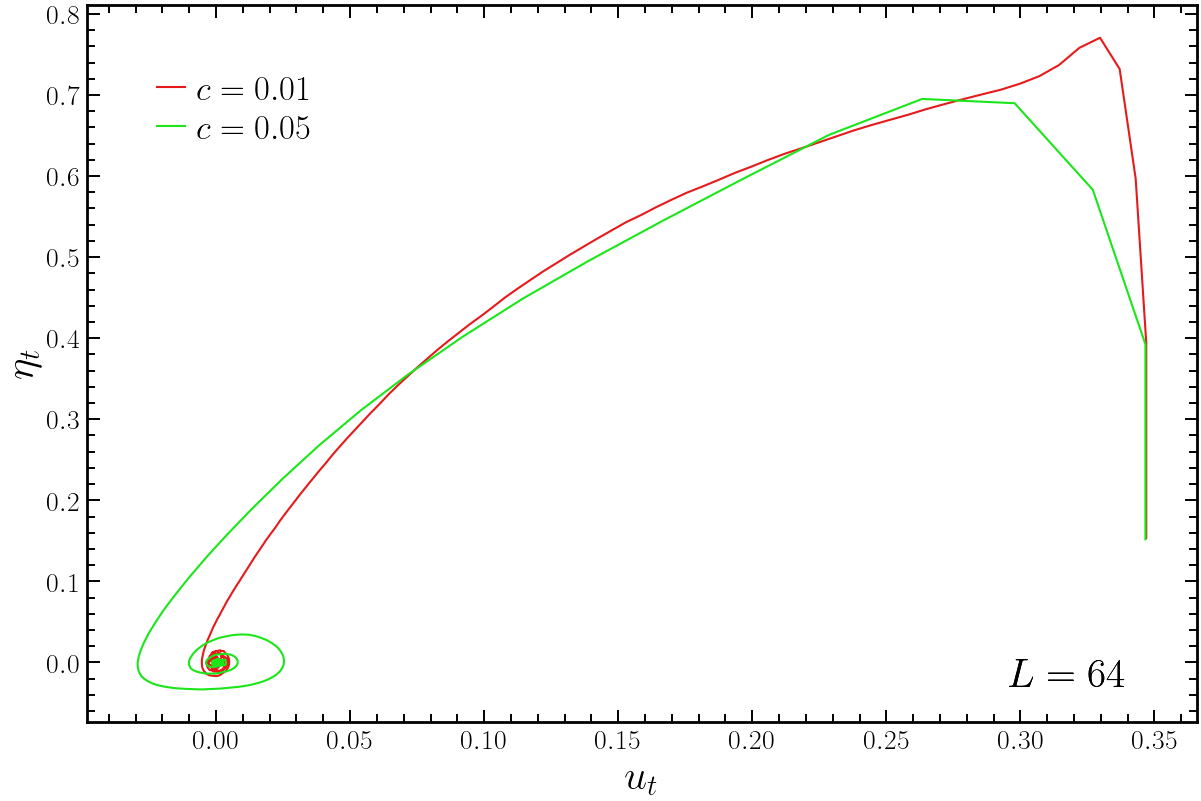

In [27]:
L = 64
#c = 0.01
c_lst = [0.01, 0.05, 0.1, 0.15]
type_perc = 'bond'
dim = 3
ns = 1
rho = 1/ns
p0_target = 0.6
P0_target = 0.2
figsize =  (12, 8)
fig, ax = plt.subplots(
    figsize=figsize,
    constrained_layout=True,
    sharex=True
)
order_mean = 0
labels_fig = [r'$(a)$', r'$(b)$', r'$(c)$',r'$(d)$']
fs_l_fig = 35
fs_legend = 29
fs_title = 40
tick_size = 20
tick_label_size = 30
labels_size = 35
fs_labels_fig = 25
fs_l_fig = 35
fs_labels = 30
fs_legend = 25
fs_labels_fig = 30
colors = (0.9,0.1,0.1),(0.1,0.9,0.1),(0.1,0.1,0.9),(0.8,0.2,0.8)

c_lst = [0.01, 0.05]
ft_lst = [0.0465101, 0.0480975]

for idx, c in enumerate(c_lst):
#    fT = ft_common[ft_common['c']==c]['ft_min'].values[0]
    fT = ft_lst[idx]
    path = (
        f"../SOP_data/published_dynamic/{type_perc}_percolation/"
        f"num_colors_{ns}/dim_{dim}/L_{L}/"
        f"fT_constant/fT_{fT:.6e}/"
        f"c_{c:.6e}/rho_{rho:.4e}/"
    )

    fn = "properties_dynamic_bundle.json"
    df_bundle = read_dynamic_bundle(path + fn)
    
    row = df_bundle[(df_bundle["P0"] == P0_target) & (df_bundle["p0"] == p0_target) & (df_bundle["order"] == 0)].iloc[0]

    time = row["time"]
    pt_mean = row["pt_mean"]
    ft_mean = row["ft_mean"]
    t_eq = row["t_eq"]
    p_star = row["p_star"]

    t = np.array(time)
    u_t = np.array(pt_mean) - p_star
    eta_t = np.array(ft_mean) - fT
    ax.plot(u_t, eta_t,ls='solid', color=colors[idx],label=f'$c = {c:.2f}$')
    
    
    ax.set_ylabel(r'$\eta_t$', fontsize=fs_labels)
    ax.set_xlabel('$u_t$', fontsize=fs_labels)
    ax.text(0.83, 0.05, f"$L = {L}$", transform=ax.transAxes , fontsize=fs_labels_fig)
ax.legend(
    loc="upper left",
    frameon=False,
    fontsize=fs_legend,
    handlelength=0.8,
    borderaxespad=1.8
)
#plt.savefig(configurations_folder + f'/L_{L}_multiply_c.pdf')
plt.show()

### size effects - $L$

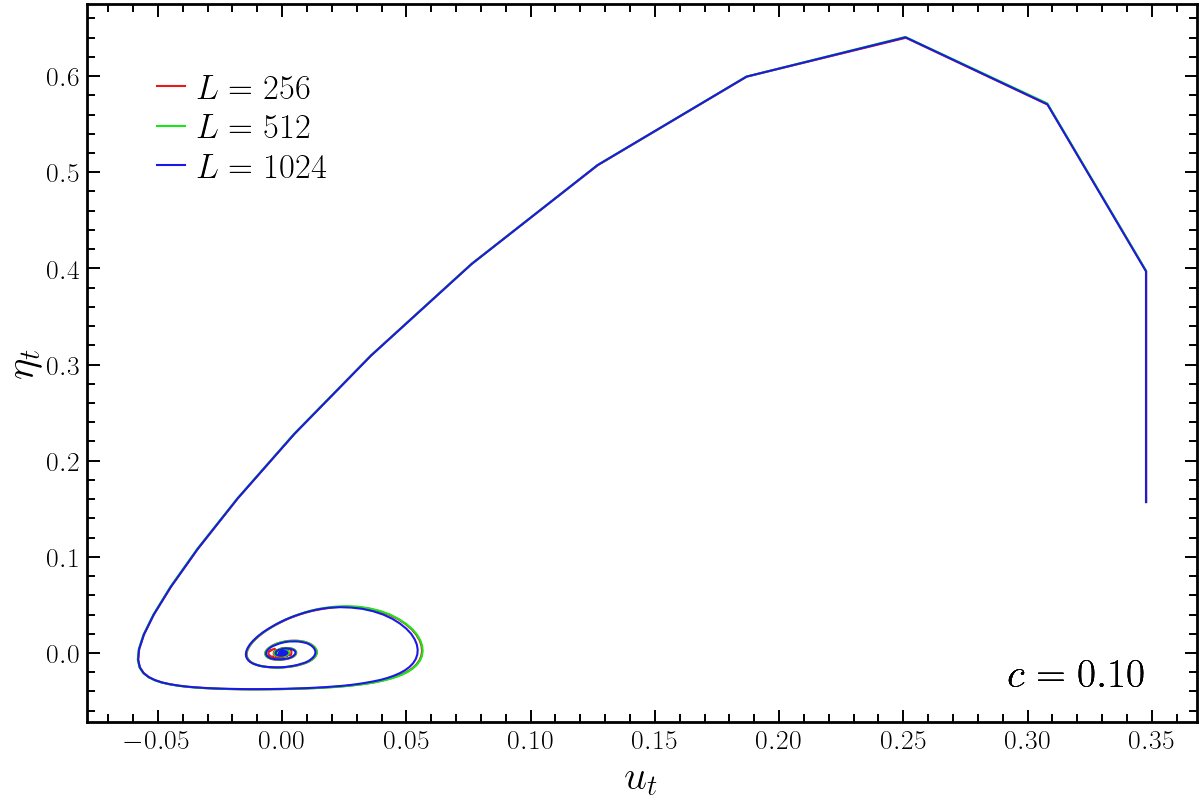

In [17]:
L_lst = [256, 512, 1024]
#c = 0.01
c = 0.1
type_perc = 'bond'
dim = 3
ns = 1
rho = 1/ns
p0_target = 0.6
P0_target = 0.2
figsize =  (12, 8)
fig, ax = plt.subplots(
    figsize=figsize,
    constrained_layout=True,
    sharex=True
)
order_mean = 0
labels_fig = [r'$(a)$', r'$(b)$', r'$(c)$',r'$(d)$']
fs_l_fig = 35
fs_legend = 29
fs_title = 40
tick_size = 20
tick_label_size = 30
labels_size = 35
fs_labels_fig = 25
fs_l_fig = 35
fs_labels = 30
fs_legend = 25
fs_labels_fig = 30
colors = (0.9,0.1,0.1),(0.1,0.9,0.1),(0.1,0.1,0.9),(0.8,0.2,0.8)

for idx, L in enumerate(L_lst):
    fT = ft_common[ft_common['c']==c]['ft_min'].values[0]
    path = (
        f"../SOP_data/published_dynamic/{type_perc}_percolation/"
        f"num_colors_{ns}/dim_{dim}/L_{L}/"
        f"fT_constant/fT_{fT:.6e}/"
        f"c_{c:.6e}/rho_{rho:.4e}/"
    )

    fn = "properties_dynamic_bundle.json"
    df_bundle = read_dynamic_bundle(path + fn)
    
    row = df_bundle[(df_bundle["P0"] == P0_target) & (df_bundle["p0"] == p0_target) & (df_bundle["order"] == 0)].iloc[0]

    time = row["time"]
    pt_mean = row["pt_mean"]
    ft_mean = row["ft_mean"]
    t_eq = row["t_eq"]
    p_star = row["p_star"]

    t = np.array(time)
    u_t = np.array(pt_mean) - p_star
    eta_t = np.array(ft_mean) - fT
    ax.plot(u_t, eta_t, ls='solid', color=colors[idx],label=f'$L = {L}$')
    
    
    ax.set_ylabel(r'$\eta_t$', fontsize=fs_labels)
    ax.set_xlabel('$u_t$', fontsize=fs_labels)
    ax.text(0.83, 0.05, f"$c = {c:.2f}$", transform=ax.transAxes , fontsize=fs_labels_fig)
ax.legend(
    loc="upper left",
    frameon=False,
    fontsize=fs_legend,
    handlelength=0.8,
    borderaxespad=1.8
)
plt.savefig(configurations_folder + f'/c_{c}_multiply_L.pdf')
plt.show()

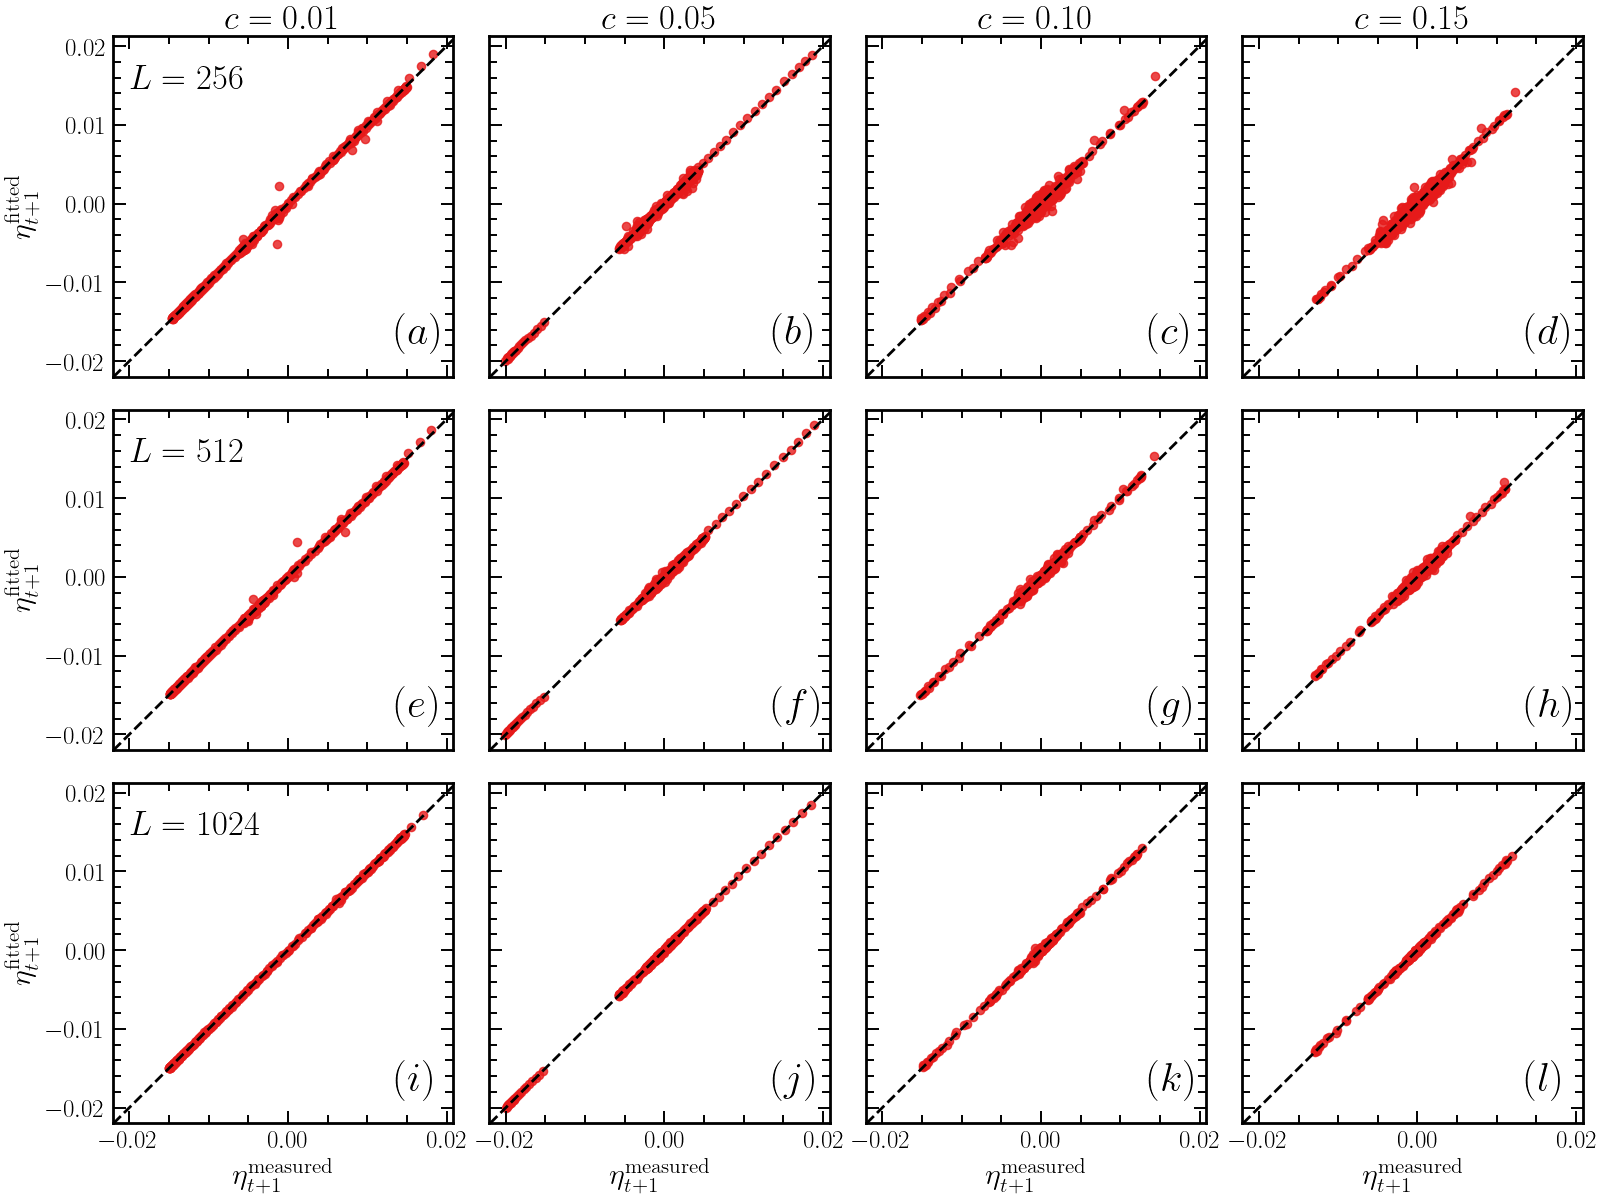

In [20]:
L_lst = [256, 512, 1024]
P0_target = 0.2
p0_target = 0.6
type_perc = 'bond'
dim = 3
ns = 1
rho = 1 / ns
fs_l_fig = 30
c_lst = [0.01, 0.05, 0.10, 0.15]

base = 4

fig, axes = plt.subplots(
    len(L_lst),
    len(c_lst),
    figsize=(len(c_lst) * base, len(L_lst) * base),
    constrained_layout=True,
    sharey=True,
    sharex=True,
)

# Caso len(L_lst)=1 ou len(c_lst)=1, garante formato 2D
axes = np.asarray(axes)
if axes.ndim == 1:
    axes = axes.reshape(len(L_lst), len(c_lst))

for idx_L, L in enumerate(L_lst):
    for idx_c, c in enumerate(c_lst):

        ax = axes[idx_L, idx_c]

        fT = ft_common[ft_common['c'] == c]['ft_min'].values[0]

        path = (
            f"../SOP_data/published_dynamic/{type_perc}_percolation/"
            f"num_colors_{ns}/dim_{dim}/L_{L}/"
            f"fT_constant/fT_{fT:.6e}/"
            f"c_{c:.6e}/rho_{rho:.4e}/"
        )

        fn = "properties_dynamic_bundle.json"
        df_bundle = read_dynamic_bundle(path + fn)

        row = df_bundle[
            (df_bundle["P0"] == P0_target)
            & (df_bundle["p0"] == p0_target)
            & (df_bundle["order"] == 0)
        ].iloc[0]

        t = row["time"]
        p = row["pt_mean"]
        f = row["ft_mean"]
        t_stat = row["t_eq_mean"]

        res = fit_linear_feedback_model(
            t=t,
            p=p,
            f=f,
            c=c,
            fT=fT,
            t_stat=t_stat,
            memory_mode="delta_eta",
            u_max=0.03,
            eta_max=0.02,
            fit_after_t_stat=False
        )

        x = np.asarray(res["eta_next_fit"])
        y = np.asarray(res["eta_next_pred"])

        ax.scatter(
            x,
            y,
            s=35,
            alpha=0.8
        )

        min_val = min(np.min(x), np.min(y))
        max_val = max(np.max(x), np.max(y))

        ax.axline(
            (0, 0),
            slope=1,
            ls="--",
            color="black",
            lw=2.0,
            zorder=1
        )

        ax.set_box_aspect(1)

        # Título da coluna
        if idx_L == 0:
            ax.set_title(fr"$c={c:.2f}$", fontsize=25)


for idx, ax in enumerate(axes[:, 0]):
    ax.set_ylabel(r"$\eta_{t+1}^{\mathrm{fitted}}$", fontsize=22)
    ax.text(
            0.05,
            0.92,
            fr"$L={L_lst[idx]}$",
            transform=ax.transAxes,
            fontsize=25,
            va="top",
            ha="left"
            )

for ax in axes[len(L_lst)-1, :]:
    ax.set_xlabel(r"$\eta_{t+1}^{\mathrm{measured}}$", fontsize=22)

for idx, ax in enumerate(axes.flatten()):
    ax.tick_params(axis="both", which="major", labelsize=18)
    ax.minorticks_on()
    ax.text(
        0.83,
        0.10,
        label(idx),
        transform=ax.transAxes,
        fontsize=fs_l_fig
    )

#plt.savefig(f"../results/{ns}Color/3D/eta_fmin.pdf")
plt.show()

In [21]:
import numpy as np
import matplotlib.pyplot as plt


def collect_residual_data(
    L_lst,
    c_lst,
    ft_common,
    fT_col="ft_min",
    sw=300,
    P0_target=1.0,
    p0_target=0.6,
    type_perc="bond",
    dim=3,
    ns=1,
    rho=None,
    order=0,
    memory_mode="delta_eta",
    u_max=0.03,
    eta_max=0.02,
    fit_after_t_stat=False,
):
    """
    Coleta os dados de ajuste e resíduos para todos os pares (L, c).
    """

    if rho is None:
        rho = 1 / ns

    data = {}

    for L in L_lst:
        for c in c_lst:

            fT = ft_common[ft_common["c"] == c][fT_col].values[0]

            path = (
                f"../SOP_data/published_dynamic/{type_perc}_percolation/"
                f"num_colors_{ns}/dim_{dim}/L_{L}/"
                f"fT_constant/fT_{fT:.6e}/"
                f"c_{c:.6e}/rho_{rho:.4e}/stationary_window_{sw}/"
            )

            fn = "properties_dynamic_bundle.json"
            df_bundle = read_dynamic_bundle(path + fn)

            row = df_bundle[
                (df_bundle["P0"] == P0_target)
                & (df_bundle["p0"] == p0_target)
                & (df_bundle["order"] == order)
            ].iloc[0]

            t = row["time"]
            p = row["pt_mean"]
            f = row["ft_mean"]
            t_stat = row["t_eq_mean"]

            res = fit_linear_feedback_model(
                t=t,
                p=p,
                f=f,
                c=c,
                fT=fT,
                t_stat=t_stat,
                memory_mode=memory_mode,
                u_max=u_max,
                eta_max=eta_max,
                fit_after_t_stat=fit_after_t_stat,
            )

            eta_measured = np.asarray(res["eta_next_fit"])
            eta_fitted = np.asarray(res["eta_next_pred"])
            residual = eta_measured - eta_fitted

            data[(L, c)] = {
                "fT": fT,
                "res": res,
                "u": np.asarray(res["u_fit"]),
                "eta": np.asarray(res["eta_fit"]),
                "eta_measured": eta_measured,
                "eta_fitted": eta_fitted,
                "residual": residual,
                "rmse": np.sqrt(np.mean(residual**2)),
                "mean_residual": np.mean(residual),
                "std_residual": np.std(residual),
            }

    return data

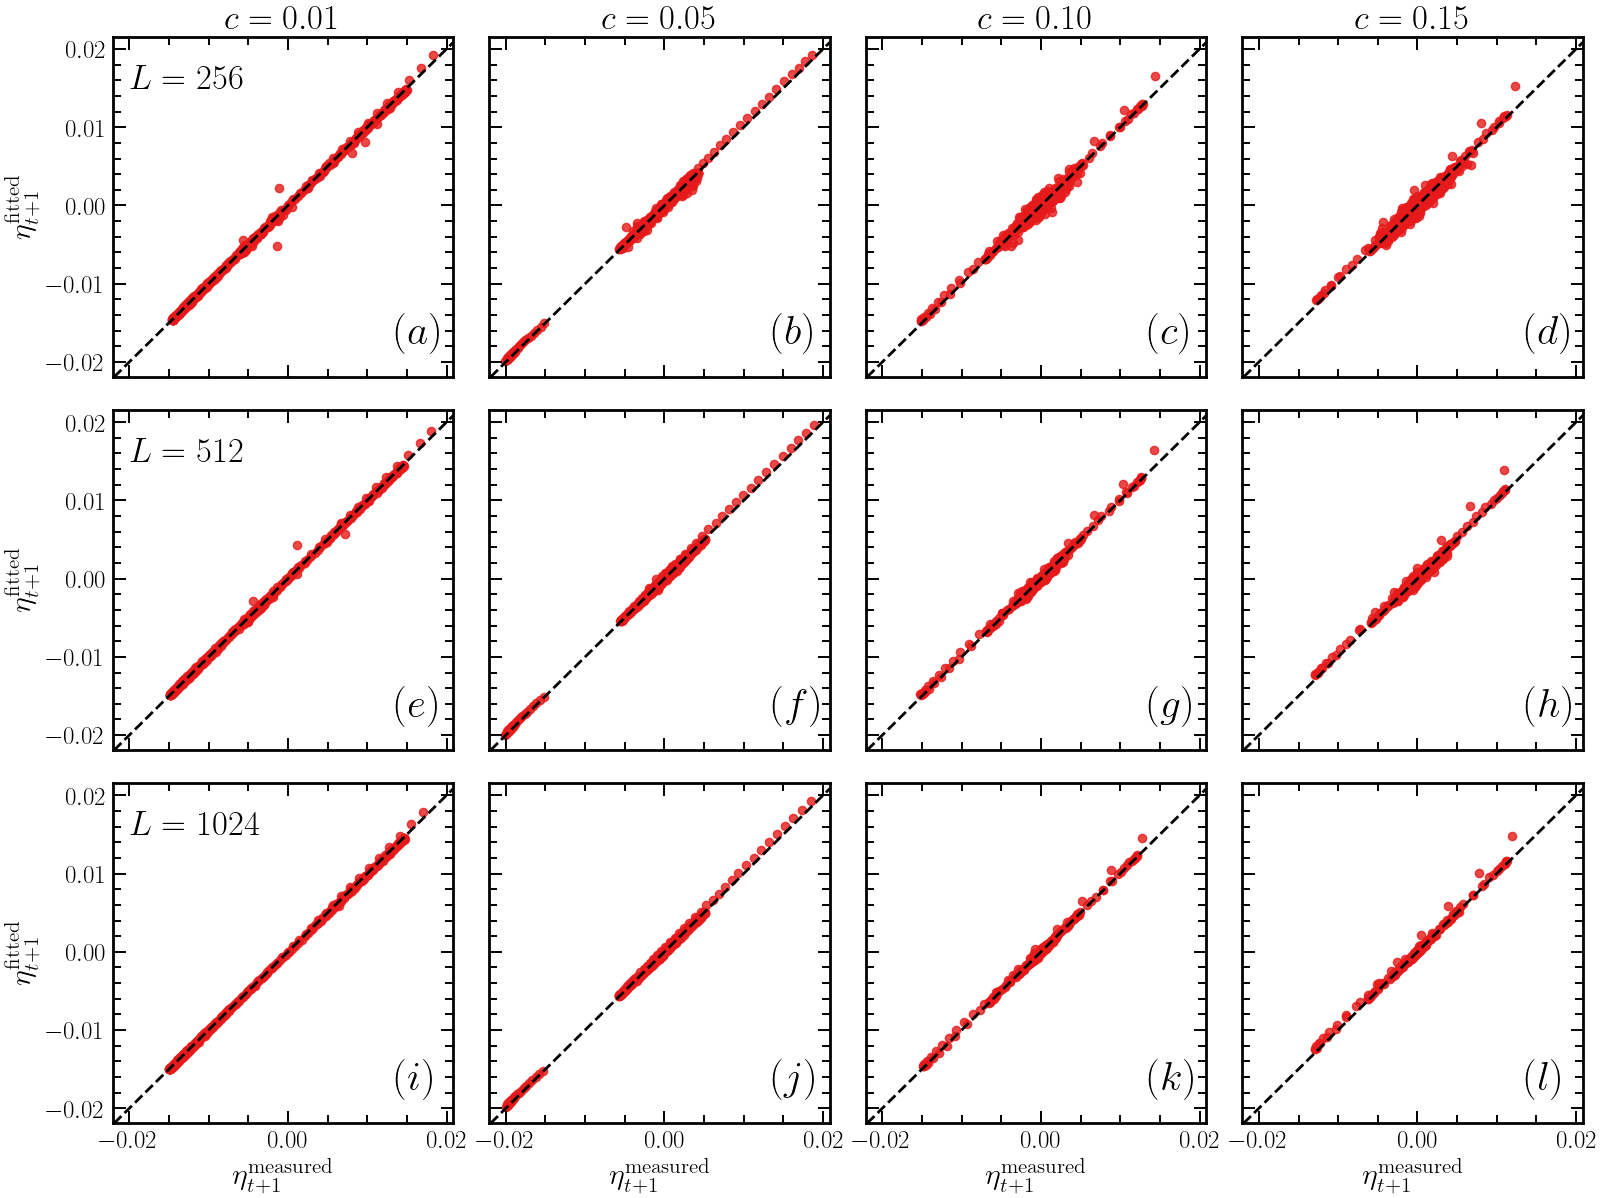

In [ ]:
L_lst = [256, 512, 1024]

P0_target = 0.2
p0_target = 0.6
type_perc = 'bond'
dim = 3
ns = 1
rho = 1 / ns
fs_l_fig = 30
c_lst = [0.01, 0.05, 0.10, 0.15]

base = 4

fig, axes = plt.subplots(
    len(L_lst),
    len(c_lst),
    figsize=(len(c_lst) * base, len(L_lst) * base),
    constrained_layout=True,
    sharey=True,
    sharex=True,
)

# Caso len(L_lst)=1 ou len(c_lst)=1, garante formato 2D
axes = np.asarray(axes)
if axes.ndim == 1:
    axes = axes.reshape(len(L_lst), len(c_lst))
mode = 'standard'
for idx_L, L in enumerate(L_lst):
    for idx_c, c in enumerate(c_lst):

        ax = axes[idx_L, idx_c]

        fT = ft_common[ft_common['c'] == c]['ft_max'].values[0]

        path = (
            f"../SOP_data/published_dynamic/{type_perc}_percolation/"
            f"num_colors_{ns}/dim_{dim}/L_{L}/"
            f"fT_constant/fT_{fT:.6e}/"
            f"c_{c:.6e}/rho_{rho:.4e}/"
        )

        fn = "properties_dynamic_bundle.json"
        df_bundle = read_dynamic_bundle(path + fn)

        row = df_bundle[
            (df_bundle["P0"] == P0_target)
            & (df_bundle["p0"] == p0_target)
            & (df_bundle["order"] == 0)
        ].iloc[0]

        t = row["time"]
        p = row["pt_mean"]
        f = row["ft_mean"]
        t_stat = row["t_eq_mean"]
        
        res = fit_linear_feedback_model(
            t=t,
            p=p,
            f=f,
            c=c,
            fT=fT,
            t_stat=t_stat,
            memory_mode=None,
            u_max=0.03,
            eta_max=0.02,
            fit_after_t_stat=False
        )

        x = np.asarray(res["eta_next_fit"])
        y = np.asarray(res["eta_next_pred"])

        ax.scatter(
            x,
            y,
            s=35,
            alpha=0.8
        )

        min_val = min(np.min(x), np.min(y))
        max_val = max(np.max(x), np.max(y))

        ax.axline(
            (0, 0),
            slope=1,
            ls="--",
            color="black",
            lw=2.0,
            zorder=1
        )

        ax.set_box_aspect(1)

        # Título da coluna
        if idx_L == 0:
            ax.set_title(fr"$c={c:.2f}$", fontsize=25)


for idx, ax in enumerate(axes[:, 0]):
    ax.set_ylabel(r"$\eta_{t+1}^{\mathrm{fitted}}$", fontsize=22)
    ax.text(
            0.05,
            0.92,
            fr"$L={L_lst[idx]}$",
            transform=ax.transAxes,
            fontsize=25,
            va="top",
            ha="left"
            )
for ax in axes[-1, :]:
    ax.set_xlabel(r"$\eta_{t+1}^{\mathrm{measured}}$", fontsize=22)

for idx, ax in enumerate(axes.flatten()):
    ax.tick_params(axis="both", which="major", labelsize=18)
    ax.minorticks_on()
    ax.text(
        0.83,
        0.10,
        label(idx),
        transform=ax.transAxes,
        fontsize=fs_l_fig
    )

#plt.savefig(f"../results/{ns}Color/3D/mode_{mode}.pdf")
plt.show()

In [17]:
res_linear = fit_linear_feedback_model(
    t=t,
    p=p,
    f=f,
    c=c,
    fT=fT,
    t_stat=t_stat,
    u_max=0.03,
    eta_max=0.02,
    fit_after_t_stat=False,
    memory_mode=None,
    include_intercept=False,
)

res_lag = fit_linear_feedback_model(
    t=t,
    p=p,
    f=f,
    c=c,
    fT=fT,
    t_stat=t_stat,
    u_max=0.03,
    eta_max=0.02,
    fit_after_t_stat=False,
    memory_mode="eta_lag",
    include_intercept=False,
)

res_delta = fit_linear_feedback_model(
    t=t,
    p=p,
    f=f,
    c=c,
    fT=fT,
    t_stat=t_stat,
    u_max=0.03,
    eta_max=0.02,
    fit_after_t_stat=False,
    memory_mode="delta_eta",
    include_intercept=False,
)

print("linear")
print("R2 =", res_linear["r2_eta"])
print("BIC =", res_linear["bic_eta"])
print()

print("eta_lag")
print("R2 =", res_lag["r2_eta"])
print("BIC =", res_lag["bic_eta"])
print("R_memory =", res_lag["R_memory"])
print()

print("delta_eta")
print("R2 =", res_delta["r2_eta"])
print("BIC =", res_delta["bic_eta"])
print("R_memory =", res_delta["R_memory"])

linear
R2 = 0.8538566128724618
BIC = -27078.520999679775

eta_lag
R2 = 0.8874284845939511
BIC = -27513.21935765327
R_memory = 0.364333674002627

delta_eta
R2 = 0.8874284845939511
BIC = -27513.219357653263
R_memory = 0.20177009988526617


In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import comb


def label(i):
    """
    Retorna labels (a), (b), (c), ...
    """
    letters = "abcdefghijklmnopqrstuvwxyz"
    if i < 26:
        return rf"$({letters[i]})$"

    # Caso passe de z: aa, ab, ...
    out = ""
    n = i
    while True:
        out = letters[n % 26] + out
        n = n // 26 - 1
        if n < 0:
            break
    return rf"$({out})$"


def polynomial_feature_matrix(u, eta, degree=1, include_intercept=True):
    """
    Monta a matriz de features polinomiais em u e eta até uma dada ordem.

    degree = 1:
        1, u, eta

    degree = 2:
        1, u, eta, u^2, u eta, eta^2

    degree = 3:
        1, u, eta, u^2, u eta, eta^2, u^3, u^2 eta, u eta^2, eta^3
    """
    u = np.asarray(u, dtype=float)
    eta = np.asarray(eta, dtype=float)

    cols = []
    names = []

    if include_intercept:
        cols.append(np.ones_like(u))
        names.append("1")

    for deg in range(1, degree + 1):
        for i in range(deg, -1, -1):
            j = deg - i
            cols.append((u ** i) * (eta ** j))

            if i == 0:
                names.append(f"eta^{j}" if j > 1 else "eta")
            elif j == 0:
                names.append(f"u^{i}" if i > 1 else "u")
            else:
                u_name = f"u^{i}" if i > 1 else "u"
                eta_name = f"eta^{j}" if j > 1 else "eta"
                names.append(f"{u_name} {eta_name}")

    X = np.column_stack(cols)
    return X, names


def fit_effective_eta_model(
    t,
    p,
    f,
    fT,
    t_stat=None,
    degree=1,
    include_intercept=False,
    u_max=None,
    eta_max=None,
    fit_after_t_stat=False,
    p_star=None,
):
    """
    Ajusta o mapa efetivo

        eta_{t+1} = H(u_t, eta_t)

    com

        u_t   = p_t - p_star
        eta_t = f_t - fT

    O ajuste é polinomial em u_t e eta_t.

    Parâmetros
    ----------
    degree:
        Ordem do polinômio.
        degree=1 -> modelo linear
        degree=2 -> modelo quadrático
        degree=3 -> modelo cúbico

    include_intercept:
        Se True, inclui termo constante h0.

    fit_after_t_stat:
        Se True, ajusta apenas pontos com t >= t_stat.
        Se False, usa todos os pontos que passam nos cortes u_max e eta_max.

    p_star:
        Se None, estima como média de p para t >= t_stat.
        Se quiser controlar manualmente, passe um valor explícito.
    """

    t = np.asarray(t, dtype=float)
    p = np.asarray(p, dtype=float)
    f = np.asarray(f, dtype=float)

    # Estados no tempo t e alvo no tempo t+1
    t_cur = t[:-1]
    p_cur = p[:-1]
    f_cur = f[:-1]
    f_next = f[1:]

    eta_cur_raw = f_cur - fT
    eta_next = f_next - fT

    # Máscara inicial de valores finitos
    mask_base = (
        np.isfinite(t_cur)
        & np.isfinite(p_cur)
        & np.isfinite(f_cur)
        & np.isfinite(eta_next)
    )

    # Estima p_star usando a região estacionária, se possível
    if p_star is None:
        if t_stat is not None:
            mask_stat = mask_base & (t_cur >= t_stat)
            if np.sum(mask_stat) >= 5:
                p_star = np.mean(p_cur[mask_stat])
            else:
                p_star = np.mean(p_cur[mask_base])
        else:
            p_star = np.mean(p_cur[mask_base])

    u_cur = p_cur - p_star
    eta_cur = eta_cur_raw

    mask = mask_base.copy()

    if fit_after_t_stat and (t_stat is not None):
        mask &= t_cur >= t_stat

    if u_max is not None:
        mask &= np.abs(u_cur) <= u_max

    if eta_max is not None:
        mask &= np.abs(eta_cur) <= eta_max

    u_fit = u_cur[mask]
    eta_fit = eta_cur[mask]
    y_true = eta_next[mask]

    X, names = polynomial_feature_matrix(
        u_fit,
        eta_fit,
        degree=degree,
        include_intercept=include_intercept
    )

    coeffs, residuals_lstsq, rank, svals = np.linalg.lstsq(X, y_true, rcond=None)
    y_pred = X @ coeffs

    residual = y_true - y_pred

    n = len(y_true)
    k = X.shape[1]

    rss = np.sum(residual ** 2)
    tss = np.sum((y_true - np.mean(y_true)) ** 2)

    rmse = np.sqrt(np.mean(residual ** 2))
    mae = np.mean(np.abs(residual))
    r2 = np.nan if tss == 0 else 1.0 - rss / tss

    # AIC/BIC gaussianos, com proteção contra log(0)
    eps = 1e-300
    aic = n * np.log(rss / n + eps) + 2 * k
    bic = n * np.log(rss / n + eps) + k * np.log(n)

    coeff_dict = {name: coeff for name, coeff in zip(names, coeffs)}

    # Razão entre contribuição não linear e linear
    linear_part = np.zeros_like(y_true)

    if "u" in coeff_dict:
        linear_part += coeff_dict["u"] * u_fit

    if "eta" in coeff_dict:
        linear_part += coeff_dict["eta"] * eta_fit

    total_without_intercept = y_pred.copy()
    if "1" in coeff_dict:
        total_without_intercept -= coeff_dict["1"]

    nonlinear_part = total_without_intercept - linear_part

    linear_rms = np.sqrt(np.mean(linear_part ** 2))
    nonlinear_rms = np.sqrt(np.mean(nonlinear_part ** 2))

    if linear_rms > 0:
        R_NL = nonlinear_rms / linear_rms
    else:
        R_NL = np.nan

    return {
        "degree": degree,
        "include_intercept": include_intercept,
        "p_star": p_star,
        "names": names,
        "coeffs": coeffs,
        "coeff_dict": coeff_dict,
        "u_fit": u_fit,
        "eta_fit": eta_fit,
        "eta_next_fit": y_true,      # measured
        "eta_next_pred": y_pred,     # fitted/predicted
        "residual": residual,
        "n": n,
        "k": k,
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "aic": aic,
        "bic": bic,
        "R_NL": R_NL,
    }


def test_models_for_row(
    t,
    p,
    f,
    fT,
    t_stat,
    u_max=0.03,
    eta_max=0.02,
    fit_after_t_stat=False,
):
    """
    Roda os quatro modelos principais.
    """

    models = {
        "linear": {
            "degree": 1,
            "include_intercept": False,
        },
        "linear_const": {
            "degree": 1,
            "include_intercept": True,
        },
        "quadratic_const": {
            "degree": 2,
            "include_intercept": True,
        },
        "cubic_const": {
            "degree": 3,
            "include_intercept": True,
        },
    }

    results = {}

    # Usa o mesmo p_star para todos os modelos
    # Isso evita que diferenças pequenas de centralização contaminem a comparação.
    t_arr = np.asarray(t, dtype=float)
    p_arr = np.asarray(p, dtype=float)

    if t_stat is not None:
        mask_stat = t_arr >= t_stat
        if np.sum(mask_stat) >= 5:
            p_star = np.mean(p_arr[mask_stat])
        else:
            p_star = np.mean(p_arr)
    else:
        p_star = np.mean(p_arr)

    for name, pars in models.items():
        results[name] = fit_effective_eta_model(
            t=t,
            p=p,
            f=f,
            fT=fT,
            t_stat=t_stat,
            degree=pars["degree"],
            include_intercept=pars["include_intercept"],
            u_max=u_max,
            eta_max=eta_max,
            fit_after_t_stat=fit_after_t_stat,
            p_star=p_star,
        )

    return results


def plot_eta_fit_tests(
    L_lst,
    c_lst,
    ft_common,
    fT_col="ft_max",
    model_to_plot="quadratic_const",
    sw=300,
    P0_target=1.0,
    p0_target=0.6,
    type_perc="bond",
    dim=3,
    ns=1,
    rho=None,
    order=0,
    base=4,
    fs_l_fig=30,
    u_max=0.03,
    eta_max=0.02,
    fit_after_t_stat=False,
    savepath=None,
):
    """
    Faz o plot measured vs fitted para um modelo escolhido e retorna métricas
    de todos os modelos.

    fT_col:
        "ft_min" ou "ft_max"

    model_to_plot:
        "linear"
        "linear_const"
        "quadratic_const"
        "cubic_const"
    """

    if rho is None:
        rho = 1 / ns

    fig, axes = plt.subplots(
        len(L_lst),
        len(c_lst),
        figsize=(len(c_lst) * base, len(L_lst) * base),
        constrained_layout=True,
        sharey=True,
        sharex=True,
    )

    axes = np.asarray(axes)
    if axes.ndim == 1:
        axes = axes.reshape(len(L_lst), len(c_lst))

    metrics_rows = []
    all_results = {}

    for idx_L, L in enumerate(L_lst):
        for idx_c, c in enumerate(c_lst):

            ax = axes[idx_L, idx_c]

            fT = ft_common.loc[ft_common["c"] == c, fT_col].values[0]

            path = (
                f"../SOP_data/published_dynamic/{type_perc}_percolation/"
                f"num_colors_{ns}/dim_{dim}/L_{L}/"
                f"fT_constant/fT_{fT:.6e}/"
                f"c_{c:.6e}/rho_{rho:.4e}/stationary_window_{sw}/"
            )

            fn = "properties_dynamic_bundle.json"
            df_bundle = read_dynamic_bundle(path + fn)

            row = df_bundle[
                (df_bundle["P0"] == P0_target)
                & (df_bundle["p0"] == p0_target)
                & (df_bundle["order"] == order)
            ].iloc[0]

            t = row["time"]
            p = row["pt_mean"]
            f = row["ft_mean"]
            t_stat = row["t_eq_mean"]

            results = test_models_for_row(
                t=t,
                p=p,
                f=f,
                fT=fT,
                t_stat=t_stat,
                u_max=u_max,
                eta_max=eta_max,
                fit_after_t_stat=fit_after_t_stat,
            )

            all_results[(L, c)] = results

            for model_name, res in results.items():
                metric_row = {
                    "fT_col": fT_col,
                    "L": L,
                    "c": c,
                    "fT": fT,
                    "model": model_name,
                    "degree": res["degree"],
                    "include_intercept": res["include_intercept"],
                    "p_star": res["p_star"],
                    "n": res["n"],
                    "k": res["k"],
                    "rmse": res["rmse"],
                    "mae": res["mae"],
                    "r2": res["r2"],
                    "aic": res["aic"],
                    "bic": res["bic"],
                    "R_NL": res["R_NL"],
                }

                for coeff_name, coeff_value in res["coeff_dict"].items():
                    clean_name = (
                        coeff_name
                        .replace(" ", "_")
                        .replace("^", "")
                    )
                    metric_row[f"coef_{clean_name}"] = coeff_value

                metrics_rows.append(metric_row)

            res_plot = results[model_to_plot]

            x = np.asarray(res_plot["eta_next_fit"])   # measured
            y = np.asarray(res_plot["eta_next_pred"])  # fitted

            ax.scatter(
                x,
                y,
                s=35,
                alpha=0.8
            )

            ax.axline(
                (0, 0),
                slope=1,
                ls="--",
                color="black",
                lw=2.0,
                zorder=1
            )

            ax.set_box_aspect(1)

            # Texto com métricas principais
            ax.text(
                0.05,
                0.08,
                rf"$R^2={res_plot['r2']:.4f}$" + "\n" + rf"$R_{{NL}}={res_plot['R_NL']:.3f}$",
                transform=ax.transAxes,
                fontsize=15,
                va="bottom",
                ha="left"
            )

            if idx_L == 0:
                ax.set_title(fr"$c={c:.2f}$", fontsize=25)

    for idx, ax in enumerate(axes[:, 0]):
        ax.set_ylabel(r"$\eta_{t+1}^{\mathrm{fitted}}$", fontsize=22)
        ax.text(
            0.05,
            0.92,
            fr"$L={L_lst[idx]}$",
            transform=ax.transAxes,
            fontsize=25,
            va="top",
            ha="left"
        )

    for ax in axes[len(L_lst)-1, :]:
        ax.set_xlabel(r"$\eta_{t+1}^{\mathrm{measured}}$", fontsize=22)

    for idx, ax in enumerate(axes.flatten()):
        ax.tick_params(axis="both", which="major", labelsize=18)
        ax.minorticks_on()
        ax.text(
            0.83,
            0.10,
            label(idx),
            transform=ax.transAxes,
            fontsize=fs_l_fig
        )

    fig.suptitle(
        rf"$f_T={fT_col}$, model: {model_to_plot.replace('_', r'\_')}",
        fontsize=26
    )

    if savepath is not None:
        plt.savefig(savepath, bbox_inches="tight")

    metrics_df = pd.DataFrame(metrics_rows)

    return fig, axes, metrics_df, all_results

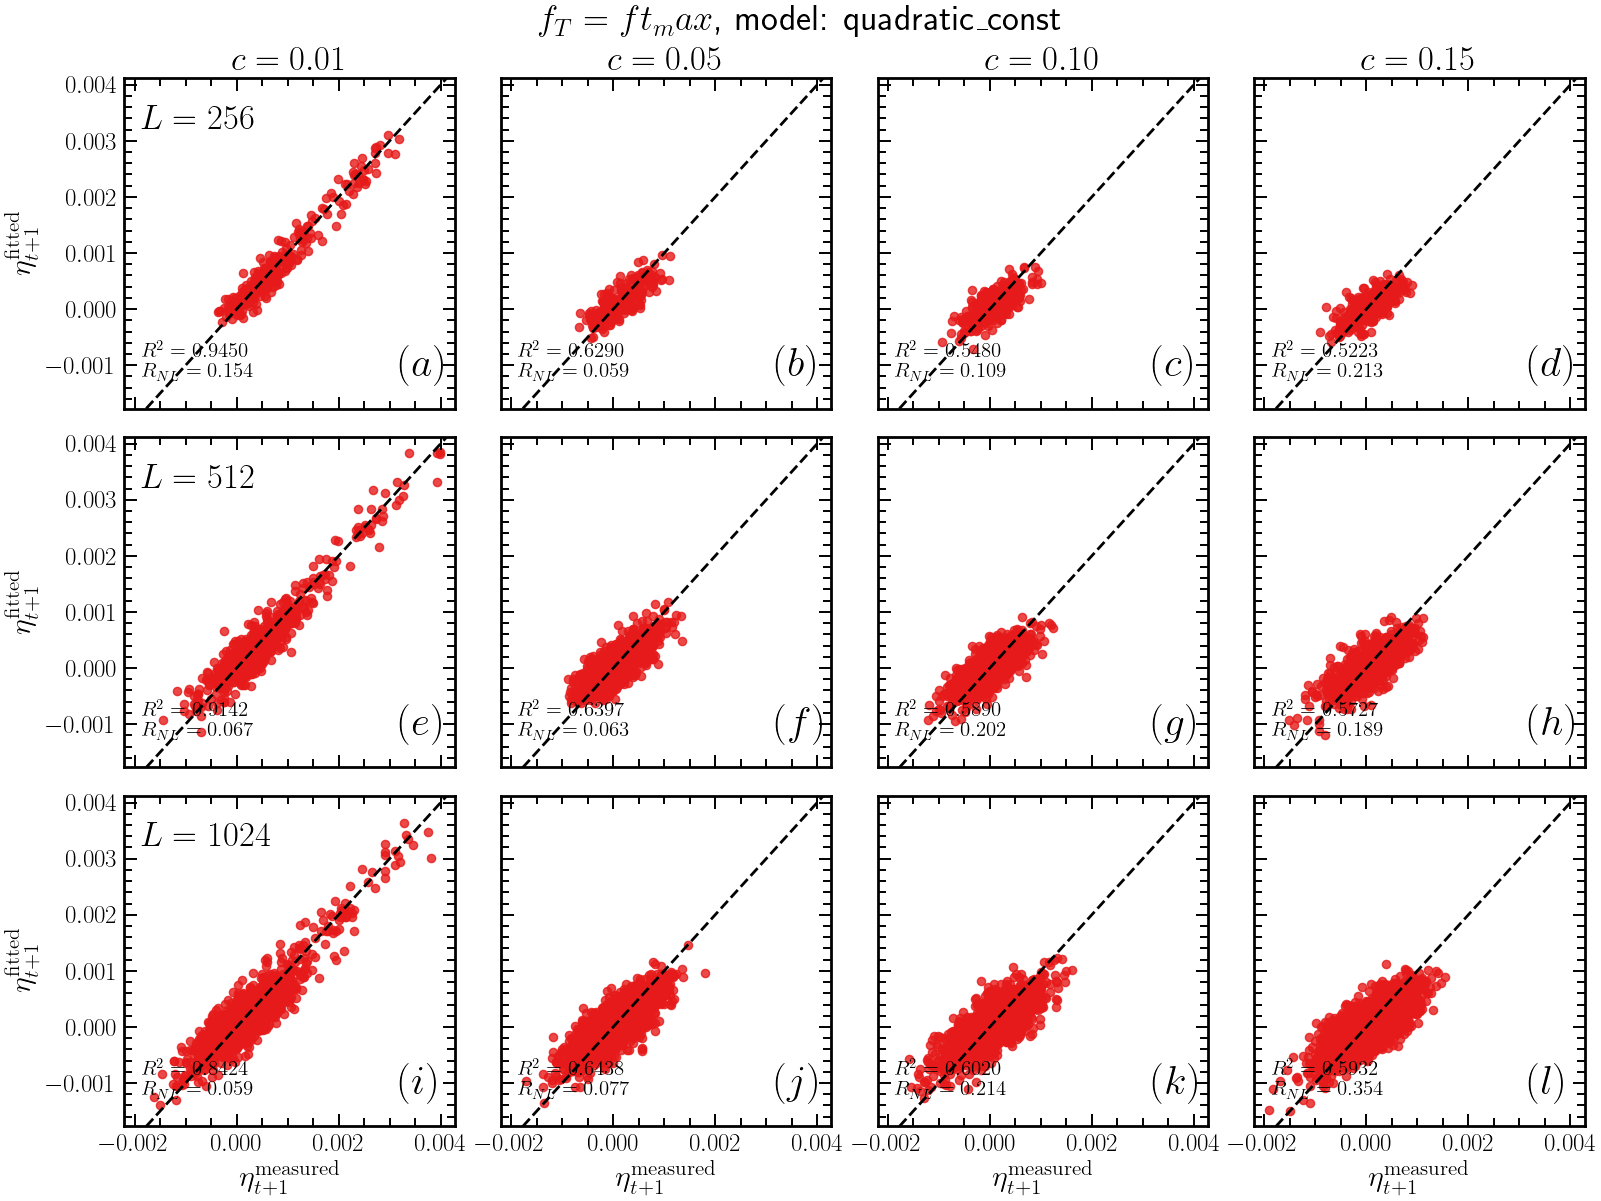

In [40]:
L_lst = [256, 512, 1024]
sw = 300
P0_target = 1.0
p0_target = 0.6
type_perc = "bond"
dim = 3
ns = 1
rho = 1 / ns
fs_l_fig = 30
c_lst = [0.01, 0.05, 0.10, 0.15]

fig, axes, metrics_fmax, results_fmax = plot_eta_fit_tests(
    L_lst=L_lst,
    c_lst=c_lst,
    ft_common=ft_common,
    fT_col="ft_max",
    model_to_plot="quadratic_const",
    sw=sw,
    P0_target=P0_target,
    p0_target=p0_target,
    type_perc=type_perc,
    dim=dim,
    ns=ns,
    rho=rho,
    order=0,
    base=4,
    fs_l_fig=fs_l_fig,
    u_max=0.03,
    eta_max=0.02,
    fit_after_t_stat=True,
    savepath='teste.pdf',
)

plt.show()

In [18]:
import numpy as np
import matplotlib.pyplot as plt


def collect_residual_data(
    L_lst,
    c_lst,
    ft_common,
    fT_col="ft_min",
    sw=300,
    P0_target=1.0,
    p0_target=0.6,
    type_perc="bond",
    dim=3,
    ns=1,
    rho=None,
    order=0,
    memory_mode="delta_eta",
    u_max=0.03,
    eta_max=0.02,
    fit_after_t_stat=False,
):
    """
    Coleta os dados de ajuste e resíduos para todos os pares (L, c).
    """

    if rho is None:
        rho = 1 / ns

    data = {}

    for L in L_lst:
        for c in c_lst:

            fT = ft_common[ft_common["c"] == c][fT_col].values[0]

            path = (
                f"../SOP_data/published_dynamic/{type_perc}_percolation/"
                f"num_colors_{ns}/dim_{dim}/L_{L}/"
                f"fT_constant/fT_{fT:.6e}/"
                f"c_{c:.6e}/rho_{rho:.4e}/stationary_window_{sw}/"
            )

            fn = "properties_dynamic_bundle.json"
            df_bundle = read_dynamic_bundle(path + fn)

            row = df_bundle[
                (df_bundle["P0"] == P0_target)
                & (df_bundle["p0"] == p0_target)
                & (df_bundle["order"] == order)
            ].iloc[0]

            t = row["time"]
            p = row["pt_mean"]
            f = row["ft_mean"]
            t_stat = row["t_eq_mean"]

            res = fit_linear_feedback_model(
                t=t,
                p=p,
                f=f,
                c=c,
                fT=fT,
                t_stat=t_stat,
                memory_mode=memory_mode,
                u_max=u_max,
                eta_max=eta_max,
                fit_after_t_stat=fit_after_t_stat,
            )

            eta_measured = np.asarray(res["eta_next_fit"])
            eta_fitted = np.asarray(res["eta_next_pred"])
            residual = eta_measured - eta_fitted

            data[(L, c)] = {
                "fT": fT,
                "res": res,
                "u": np.asarray(res["u_fit"]),
                "eta": np.asarray(res["eta_fit"]),
                "eta_measured": eta_measured,
                "eta_fitted": eta_fitted,
                "residual": residual,
                "rmse": np.sqrt(np.mean(residual**2)),
                "mean_residual": np.mean(residual),
                "std_residual": np.std(residual),
            }

    return data

In [19]:
def plot_residual_grid(
    residual_data,
    L_lst,
    c_lst,
    x_mode="eta",
    base=4,
    fs_l_fig=30,
    s=35,
    alpha=0.8,
    savepath=None,
):
    """
    Plota resíduos em uma grade L x c.

    x_mode:
        "u"        -> resíduo contra u_t
        "eta"      -> resíduo contra eta_t
        "measured" -> resíduo contra eta_{t+1}^{measured}
        "fitted"   -> resíduo contra eta_{t+1}^{fitted}
    """

    valid_modes = ["u", "eta", "measured", "fitted"]
    if x_mode not in valid_modes:
        raise ValueError(f"x_mode deve ser um destes: {valid_modes}")

    fig, axes = plt.subplots(
        len(L_lst),
        len(c_lst),
        figsize=(len(c_lst) * base, len(L_lst) * base),
        constrained_layout=True,
        sharey=True,
        sharex=True,
    )

    axes = np.asarray(axes)
    if axes.ndim == 1:
        axes = axes.reshape(len(L_lst), len(c_lst))

    # Limite simétrico global para o eixo y dos resíduos
    all_residuals = []
    all_x = []

    for L in L_lst:
        for c in c_lst:
            d = residual_data[(L, c)]
            r = d["residual"]

            if x_mode == "u":
                x = d["u"]
            elif x_mode == "eta":
                x = d["eta"]
            elif x_mode == "measured":
                x = d["eta_measured"]
            elif x_mode == "fitted":
                x = d["eta_fitted"]

            all_residuals.append(r)
            all_x.append(x)

    all_residuals = np.concatenate(all_residuals)
    all_x = np.concatenate(all_x)

    y_abs = np.nanmax(np.abs(all_residuals))
    x_min = np.nanmin(all_x)
    x_max = np.nanmax(all_x)

    if y_abs == 0:
        y_abs = 1e-12

    y_lim = 1.10 * y_abs
    x_pad = 0.05 * (x_max - x_min) if x_max > x_min else 1e-12

    for idx_L, L in enumerate(L_lst):
        for idx_c, c in enumerate(c_lst):

            ax = axes[idx_L, idx_c]
            d = residual_data[(L, c)]

            r = d["residual"]

            if x_mode == "u":
                x = d["u"]
                xlabel = r"$u_t$"
            elif x_mode == "eta":
                x = d["eta"]
                xlabel = r"$\eta_t$"
            elif x_mode == "measured":
                x = d["eta_measured"]
                xlabel = r"$\eta_{t+1}^{\mathrm{measured}}$"
            elif x_mode == "fitted":
                x = d["eta_fitted"]
                xlabel = r"$\eta_{t+1}^{\mathrm{fitted}}$"

            ax.scatter(
                x,
                r,
                s=s,
                alpha=alpha,
            )

            ax.axhline(
                0.0,
                ls="--",
                color="black",
                lw=2.0,
                zorder=1,
            )

            ax.set_xlim(x_min - x_pad, x_max + x_pad)
            ax.set_ylim(-y_lim, y_lim)
            ax.set_box_aspect(1)

            rmse = d["rmse"]
            mean_r = d["mean_residual"]

            ax.text(
                0.05,
                0.08,
                rf"$\mathrm{{RMSE}}={rmse:.2e}$" + "\n" + rf"$\langle r\rangle={mean_r:.2e}$",
                transform=ax.transAxes,
                fontsize=14,
                va="bottom",
                ha="left",
            )

            if idx_L == 0:
                ax.set_title(fr"$c={c:.2f}$", fontsize=25)

    for idx, ax in enumerate(axes[:, 0]):
        ax.set_ylabel(
            r"$r_t=\eta_{t+1}^{\mathrm{measured}}-\eta_{t+1}^{\mathrm{fitted}}$",
            fontsize=19,
        )
        ax.text(
            0.05,
            0.92,
            fr"$L={L_lst[idx]}$",
            transform=ax.transAxes,
            fontsize=25,
            va="top",
            ha="left",
        )

    for ax in axes[len(L_lst) - 1, :]:
        ax.set_xlabel(xlabel, fontsize=22)

    for idx, ax in enumerate(axes.flatten()):
        ax.tick_params(axis="both", which="major", labelsize=18)
        ax.minorticks_on()
        ax.text(
            0.83,
            0.10,
            label(idx),
            transform=ax.transAxes,
            fontsize=fs_l_fig,
        )

    if savepath is not None:
        plt.savefig(savepath, bbox_inches="tight")

    return fig, axes

In [26]:
L_lst = [256, 512, 1024]
sw = 300
P0_target = 1.0
p0_target = 0.6
type_perc = "bond"
dim = 3
ns = 1
rho = 1 / ns
fs_l_fig = 30
c_lst = [0.01, 0.05, 0.10, 0.15]

residual_data_fmin = collect_residual_data(
    L_lst=L_lst,
    c_lst=c_lst,
    ft_common=ft_common,
    fT_col="ft_max",
    sw=sw,
    P0_target=P0_target,
    p0_target=p0_target,
    type_perc=type_perc,
    dim=dim,
    ns=ns,
    rho=rho,
    order=0,
    memory_mode="delta_eta",
    u_max=0.03,
    eta_max=0.02,
    fit_after_t_stat=False,
)

mean residual = -2.306570304285322e-06
std residual  = 0.0003365068490202183
RMSE residual = 0.00033651475406597643
|mean r| / std(eta) = 0.0026203069617410047
RMSE / std(eta)     = 0.382287048077146
RMSE / range(eta)   = 0.023064337195861515
resíduos indicam falha relevante do modelo


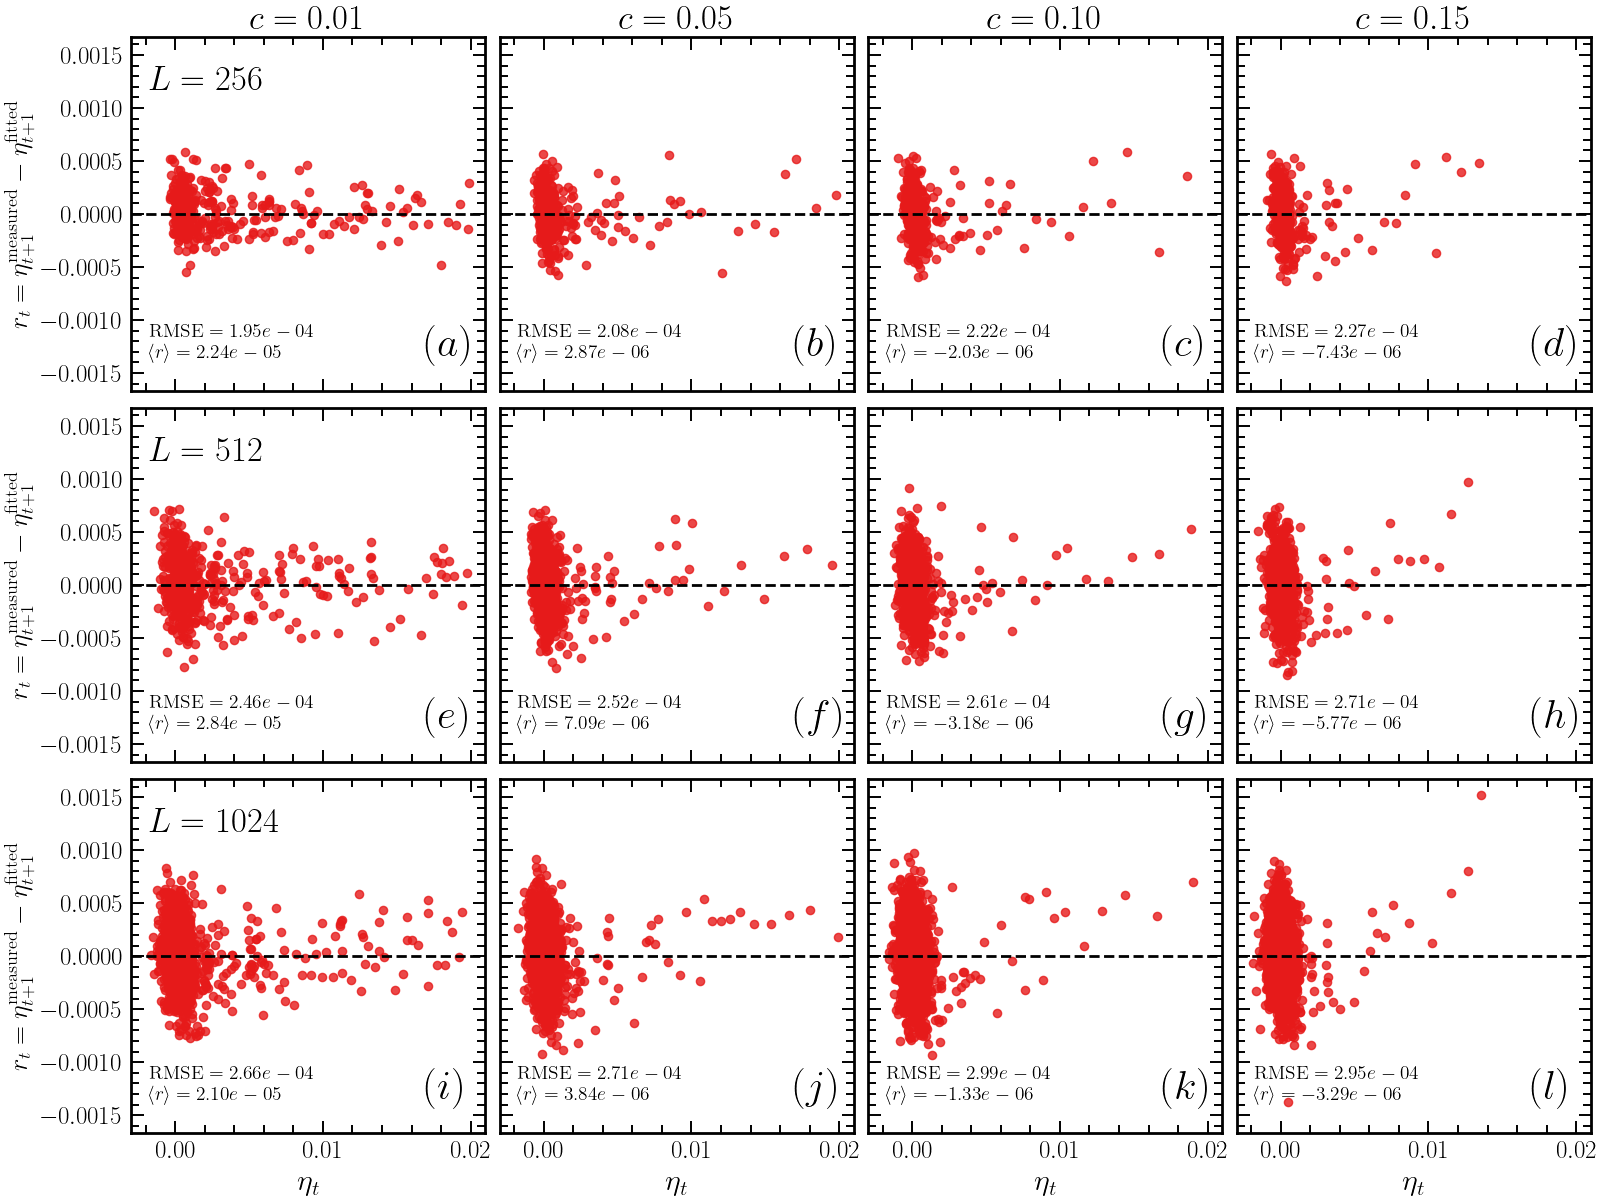

In [33]:
fig, axes = plot_residual_grid(
    residual_data=residual_data_fmin,
    L_lst=L_lst,
    c_lst=c_lst,
    x_mode="eta",
    base=4,
    fs_l_fig=fs_l_fig,
    savepath=None,
)
r = np.asarray(res["eta_next_fit"]) - np.asarray(res["eta_next_pred"])
eta_measured = np.asarray(res["eta_next_fit"])

mean_r = np.mean(r)
std_r = np.std(r)
rmse_r = np.sqrt(np.mean(r**2))

eta_scale_std = np.std(eta_measured)
eta_scale_range = np.max(eta_measured) - np.min(eta_measured)

bias_over_std = np.abs(mean_r) / eta_scale_std
rmse_over_std = rmse_r / eta_scale_std
rmse_over_range = rmse_r / eta_scale_range

print("mean residual =", mean_r)
print("std residual  =", std_r)
print("RMSE residual =", rmse_r)
print("|mean r| / std(eta) =", bias_over_std)
print("RMSE / std(eta)     =", rmse_over_std)
print("RMSE / range(eta)   =", rmse_over_range)
if bias_over_std < 0.01 and rmse_over_std < 0.10:
    print("resíduos muito bons")
elif bias_over_std < 0.05 and rmse_over_std < 0.20:
    print("resíduos aceitáveis")
else:
    print("resíduos indicam falha relevante do modelo")
plt.show()

mean residual = -2.306570304285322e-06
std residual  = 0.0003365068490202183
RMSE residual = 0.00033651475406597643
|mean r| / std(eta) = 0.0026203069617410047
RMSE / std(eta)     = 0.382287048077146
RMSE / range(eta)   = 0.023064337195861515
resíduos indicam falha relevante do modelo


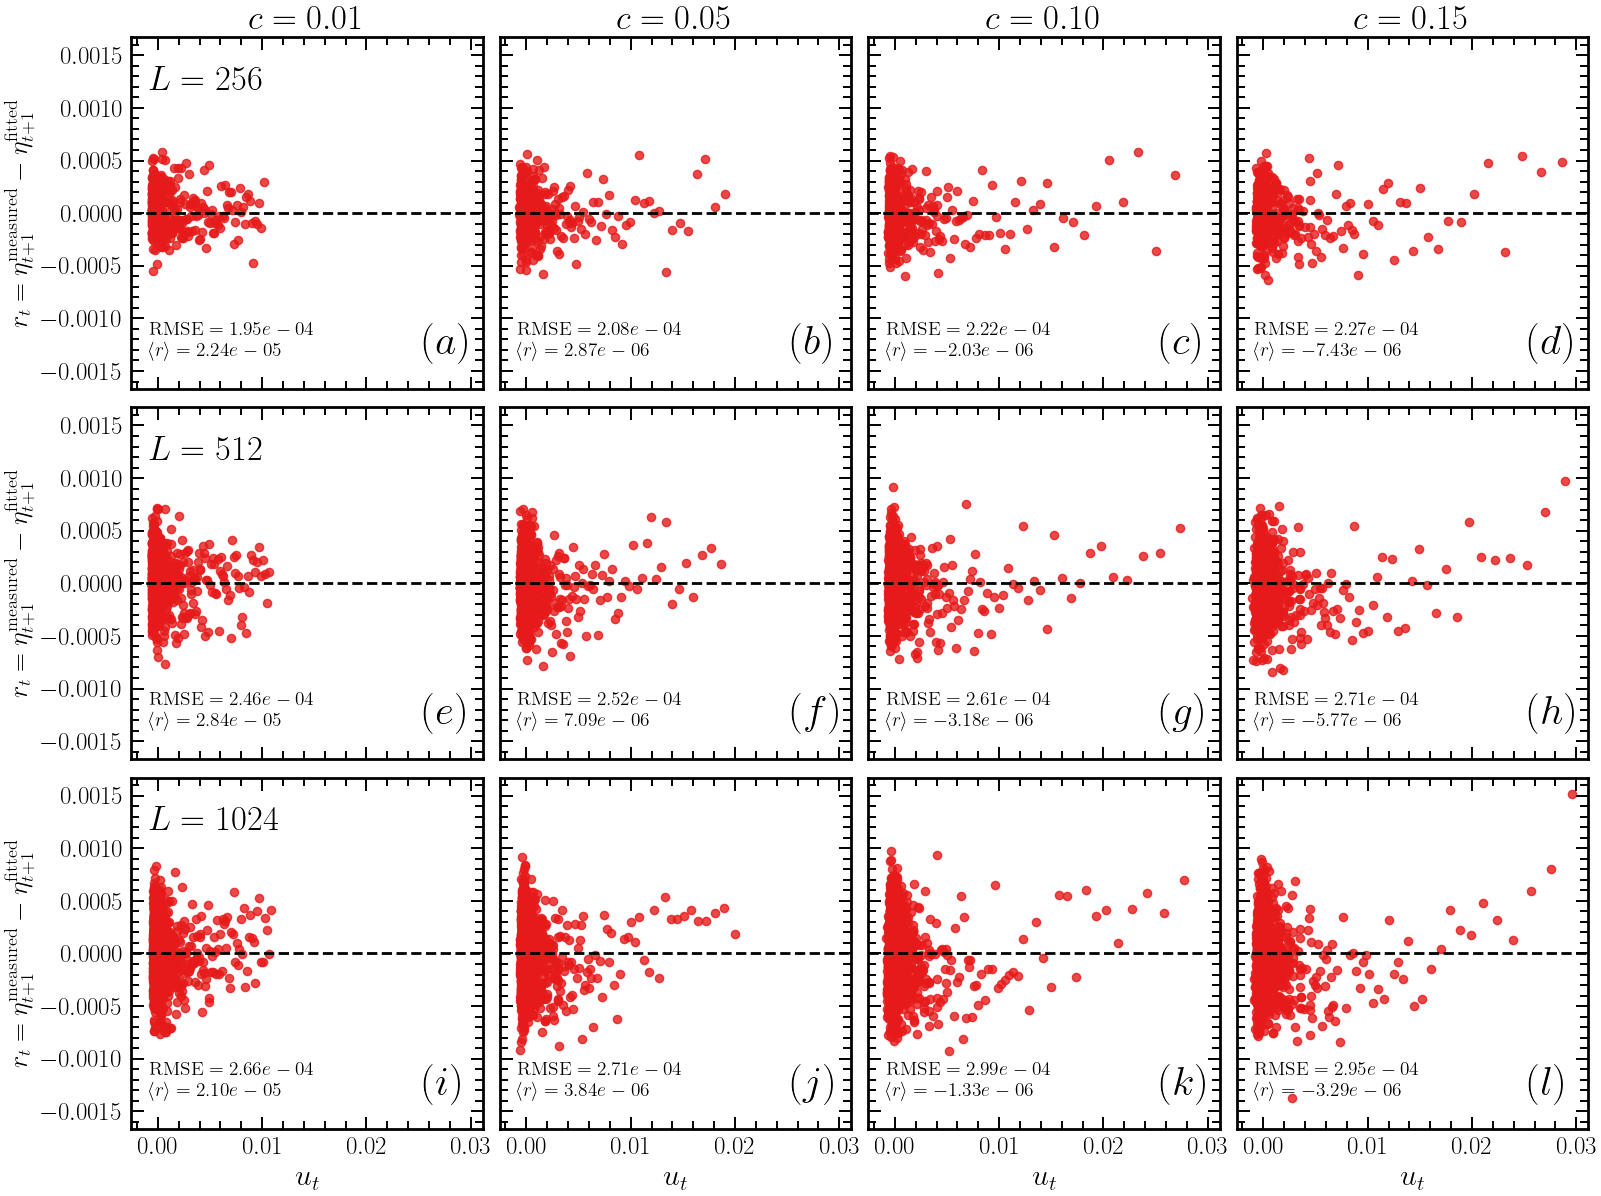

In [34]:
fig, axes = plot_residual_grid(
    residual_data=residual_data_fmin,
    L_lst=L_lst,
    c_lst=c_lst,
    x_mode="u",
    base=4,
    fs_l_fig=fs_l_fig,
    savepath=None,
)
r = np.asarray(res["eta_next_fit"]) - np.asarray(res["eta_next_pred"])
eta_measured = np.asarray(res["eta_next_fit"])

mean_r = np.mean(r)
std_r = np.std(r)
rmse_r = np.sqrt(np.mean(r**2))

eta_scale_std = np.std(eta_measured)
eta_scale_range = np.max(eta_measured) - np.min(eta_measured)

bias_over_std = np.abs(mean_r) / eta_scale_std
rmse_over_std = rmse_r / eta_scale_std
rmse_over_range = rmse_r / eta_scale_range

print("mean residual =", mean_r)
print("std residual  =", std_r)
print("RMSE residual =", rmse_r)
print("|mean r| / std(eta) =", bias_over_std)
print("RMSE / std(eta)     =", rmse_over_std)
print("RMSE / range(eta)   =", rmse_over_range)
if bias_over_std < 0.01 and rmse_over_std < 0.10:
    print("resíduos muito bons")
elif bias_over_std < 0.05 and rmse_over_std < 0.20:
    print("resíduos aceitáveis")
else:
    print("resíduos indicam falha relevante do modelo")

plt.show()

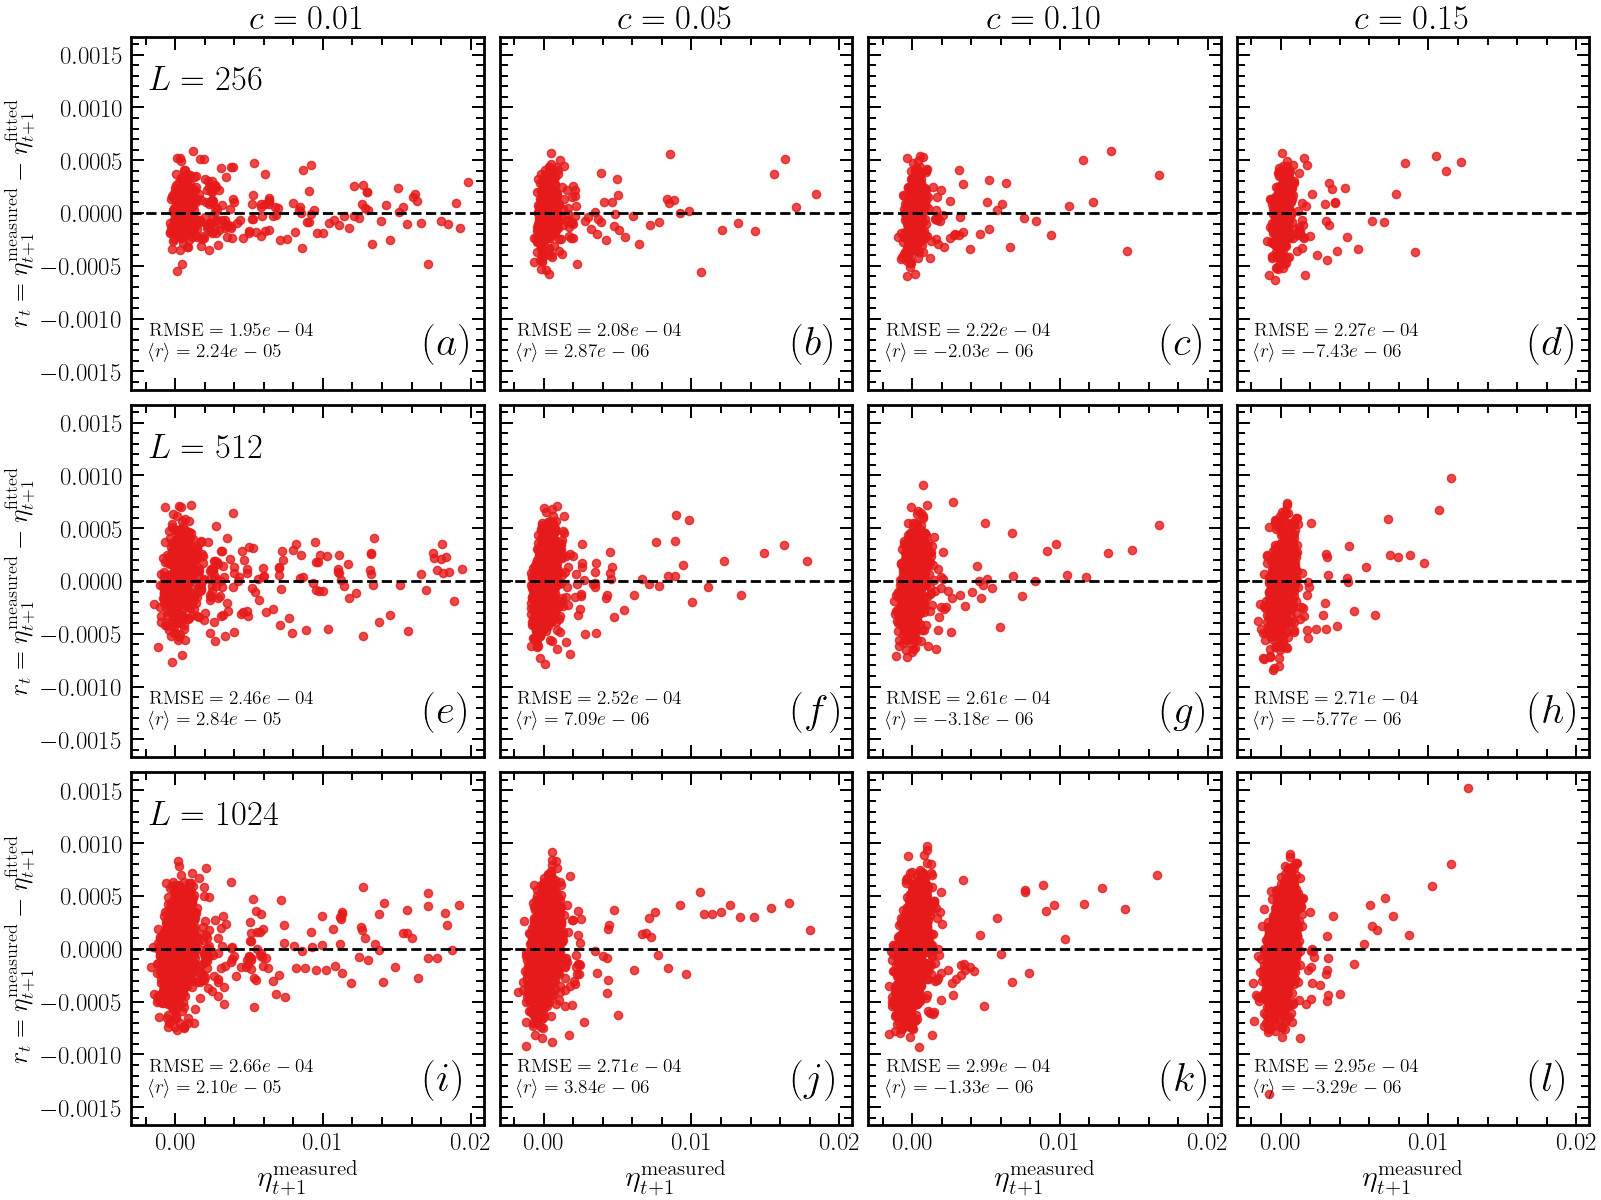

In [29]:
fig, axes = plot_residual_grid(
    residual_data=residual_data_fmin,
    L_lst=L_lst,
    c_lst=c_lst,
    x_mode="measured",
    base=4,
    fs_l_fig=fs_l_fig,
    savepath=None,
)

plt.show()

In [30]:
def plot_residual_phase_grid(
    residual_data,
    L_lst,
    c_lst,
    base=4,
    fs_l_fig=30,
    s=35,
    alpha=0.85,
    savepath=None,
):
    """
    Plota o plano (u_t, eta_t), colorindo cada ponto pelo resíduo:

        r_t = eta_{t+1}^{measured} - eta_{t+1}^{fitted}
    """

    fig, axes = plt.subplots(
        len(L_lst),
        len(c_lst),
        figsize=(len(c_lst) * base, len(L_lst) * base),
        constrained_layout=True,
        sharey=True,
        sharex=True,
    )

    axes = np.asarray(axes)
    if axes.ndim == 1:
        axes = axes.reshape(len(L_lst), len(c_lst))

    all_u = []
    all_eta = []
    all_residuals = []

    for L in L_lst:
        for c in c_lst:
            d = residual_data[(L, c)]
            all_u.append(d["u"])
            all_eta.append(d["eta"])
            all_residuals.append(d["residual"])

    all_u = np.concatenate(all_u)
    all_eta = np.concatenate(all_eta)
    all_residuals = np.concatenate(all_residuals)

    u_min, u_max = np.nanmin(all_u), np.nanmax(all_u)
    eta_min, eta_max = np.nanmin(all_eta), np.nanmax(all_eta)

    u_pad = 0.05 * (u_max - u_min) if u_max > u_min else 1e-12
    eta_pad = 0.05 * (eta_max - eta_min) if eta_max > eta_min else 1e-12

    r_abs = np.nanmax(np.abs(all_residuals))
    if r_abs == 0:
        r_abs = 1e-12

    last_sc = None

    for idx_L, L in enumerate(L_lst):
        for idx_c, c in enumerate(c_lst):

            ax = axes[idx_L, idx_c]
            d = residual_data[(L, c)]

            u = d["u"]
            eta = d["eta"]
            r = d["residual"]

            last_sc = ax.scatter(
                u,
                eta,
                c=r,
                s=s,
                alpha=alpha,
                vmin=-r_abs,
                vmax=r_abs,
            )

            ax.axhline(0.0, ls="--", color="black", lw=1.5)
            ax.axvline(0.0, ls="--", color="black", lw=1.5)

            ax.set_xlim(u_min - u_pad, u_max + u_pad)
            ax.set_ylim(eta_min - eta_pad, eta_max + eta_pad)
            ax.set_box_aspect(1)

            rmse = d["rmse"]

            ax.text(
                0.05,
                0.08,
                rf"$\mathrm{{RMSE}}={rmse:.2e}$",
                transform=ax.transAxes,
                fontsize=14,
                va="bottom",
                ha="left",
            )

            if idx_L == 0:
                ax.set_title(fr"$c={c:.2f}$", fontsize=25)

    for idx, ax in enumerate(axes[:, 0]):
        ax.set_ylabel(r"$\eta_t$", fontsize=22)
        ax.text(
            0.05,
            0.92,
            fr"$L={L_lst[idx]}$",
            transform=ax.transAxes,
            fontsize=25,
            va="top",
            ha="left",
        )

    for ax in axes[len(L_lst) - 1, :]:
        ax.set_xlabel(r"$u_t$", fontsize=22)

    for idx, ax in enumerate(axes.flatten()):
        ax.tick_params(axis="both", which="major", labelsize=18)
        ax.minorticks_on()
        ax.text(
            0.83,
            0.10,
            label(idx),
            transform=ax.transAxes,
            fontsize=fs_l_fig,
        )

    cbar = fig.colorbar(
        last_sc,
        ax=axes,
        shrink=0.85,
        pad=0.02,
    )

    cbar.set_label(
        r"$r_t=\eta_{t+1}^{\mathrm{measured}}-\eta_{t+1}^{\mathrm{fitted}}$",
        fontsize=20,
    )
    cbar.ax.tick_params(labelsize=16)

    if savepath is not None:
        plt.savefig(savepath, bbox_inches="tight")

    return fig, axes

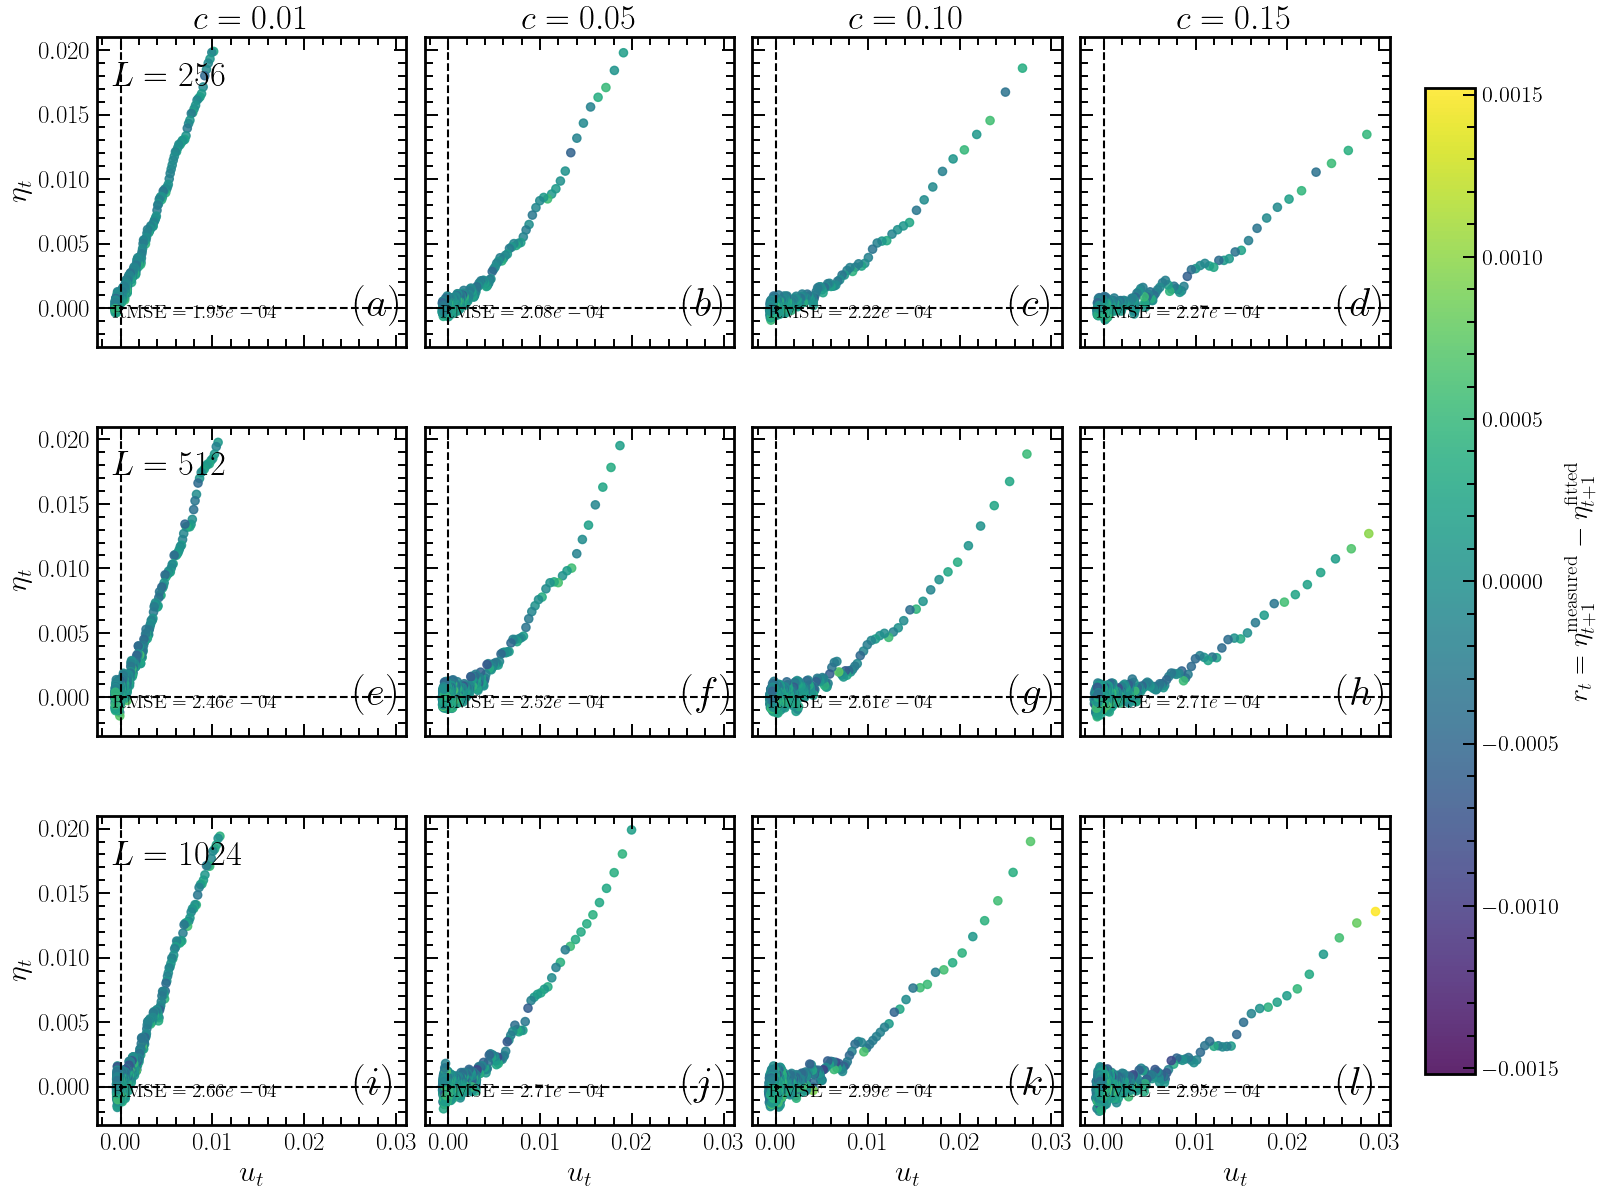

In [31]:
fig, axes = plot_residual_phase_grid(
    residual_data=residual_data_fmin,
    L_lst=L_lst,
    c_lst=c_lst,
    base=4,
    fs_l_fig=fs_l_fig,
    savepath=None,
)

plt.show()